# Task 1: Time-Series Preprocessing, EDA and Model Training
## Household Electric Power Consumption — UCI Dataset

---

## Problem Statement

This notebook addresses the problem of one-minute-ahead residential electricity demand forecasting. Given all household electricity measurements available up to time $t$, the objective is to accurately predict the global active power (kW) at time $t+1$. Accurate short-term load forecasting is fundamental to smart-grid demand-response systems, enabling energy providers to balance supply against demand, schedule storage dispatch, and reduce grid stress during peak periods.

## Dataset Justification

The UCI Individual Household Electric Power Consumption dataset was selected because it offers nearly four years of one-minute-resolution data spanning December 2006 to November 2010, yielding over two million observations. This volume is sufficient to capture daily, weekly, and seasonal demand cycles simultaneously. The target variable, `global_active_power` (kW), is a direct and physically interpretable measure of household energy demand with no proxy encoding required. The dataset also records seven simultaneous measurement channels — voltage, current intensity, reactive power, and three sub-metering circuits — enabling multivariate correlation and leakage analysis. It is a widely used benchmark in time-series forecasting research, allowing result comparison against published baselines, and residential power forecasting directly supports smart-meter analytics, demand-side management, and energy-efficiency advisory applications.

**Dataset:** Individual household electric power consumption (Dec 2006 – Nov 2010)
**Source:** UCI Machine Learning Repository via Kaggle
**Granularity:** 1-minute intervals — approximately 2.07 million records

## Notebook Structure

Section 0 covers setup: imports, paths, and configuration. Section 1A covers dataset understanding: time range, frequency, missing values, and statistical distributions. Section 1B answers six analytical questions with supporting visualisations, including lag features and moving averages. Section 1C covers model training with three experiments, hyperparameter tuning, and a full experiment comparison table.

**Target variable:** `global_active_power` (kW) — household global minute-averaged active power


## Section 0: Setup — Imports, Configuration & Paths

In [204]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import joblib
import sklearn

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "legend.fontsize": 10})

print(f"pandas {pd.__version__} | numpy {np.__version__} | sklearn {sklearn.__version__}")


pandas 3.0.1 | numpy 2.4.2 | sklearn 1.8.0


In [205]:
_cwd     = Path(os.getcwd())
BASE_DIR = _cwd if (_cwd / "household_power_consumption.txt").exists() else _cwd.parent
DATA_DIR    = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"
RAW_FILE    = BASE_DIR / "household_power_consumption.txt"

DATA_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

TARGET = "global_active_power"

FEATURE_COLS = [
    "hour_sin", "hour_cos",
    "dow_sin",  "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_5", "lag_15", "lag_60",
    "diff_1", "diff_5",
    "ma_10",  "ma_60",
    "rolling_std_10",
]

print(f"BASE_DIR    : {BASE_DIR}")
print(f"File exists : {RAW_FILE.exists()}")
print(f"Features    : {len(FEATURE_COLS)} -> {FEATURE_COLS}")


BASE_DIR    : /Users/ghz/projects/TimeSeriesDataPipeline
File exists : True
Features    : 15 -> ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_5', 'lag_15', 'lag_60', 'diff_1', 'diff_5', 'ma_10', 'ma_60', 'rolling_std_10']


In [ ]:
def resample_to_1min(df: pd.DataFrame, datetime_col: str = "datetime") -> pd.DataFrame:
    """Reindex to a complete 1-minute grid and linearly interpolate all gaps.
    Ensures every lag_N feature corresponds to exactly N minutes elapsed."""
    idx        = df.set_index(datetime_col)
    full_range = pd.date_range(start=idx.index.min(), end=idx.index.max(), freq="1min")
    n_before   = len(idx)
    nan_before = int(idx.isnull().any(axis=1).sum())   # rows with any NaN in original data
    idx        = idx.reindex(full_range)
    n_new      = len(idx) - n_before                    # new timestamp rows from gaps
    nan_interp = int(idx.isnull().any(axis=1).sum())    # total NaN rows to interpolate
    for col in idx.select_dtypes(include="number").columns:
        idx[col] = idx[col].interpolate(method="linear", limit_direction="both")
    idx = idx.dropna().rename_axis(datetime_col).reset_index()
    print(f"Resampled : {n_before:,} → {len(idx):,} rows  "
          f"({n_new:,} new timestamps added, {nan_interp:,} NaN rows interpolated)")
    return idx


def build_features(df: pd.DataFrame, target: str = "global_active_power") -> pd.DataFrame:
    """Build 15 leakage-free features from a 1-minute-resampled DataFrame.
    All lags and rolling windows use .shift(1) — no value at time t is used as input."""
    d = df.copy().sort_values("datetime").reset_index(drop=True)

    d["hour_sin"]  = np.sin(2 * np.pi * d["datetime"].dt.hour / 24)
    d["hour_cos"]  = np.cos(2 * np.pi * d["datetime"].dt.hour / 24)
    d["dow_sin"]   = np.sin(2 * np.pi * d["datetime"].dt.dayofweek / 7)
    d["dow_cos"]   = np.cos(2 * np.pi * d["datetime"].dt.dayofweek / 7)
    d["month_sin"] = np.sin(2 * np.pi * d["datetime"].dt.month / 12)
    d["month_cos"] = np.cos(2 * np.pi * d["datetime"].dt.month / 12)

    for lag in [1, 5, 15, 60]:
        d[f"lag_{lag}"] = d[target].shift(lag)

    d["diff_1"] = d[target].shift(1) - d[target].shift(2)
    d["diff_5"] = d[target].shift(1) - d[target].shift(6)

    past = d[target].shift(1)
    d["ma_10"]          = past.rolling(10, min_periods=1).mean()
    d["ma_60"]          = past.rolling(60, min_periods=1).mean()
    d["rolling_std_10"] = past.rolling(10, min_periods=2).std().fillna(0)

    return d.dropna().reset_index(drop=True)


print("resample_to_1min and build_features defined")


resample_to_1min and build_features defined


---
## Section 1A: Understanding the Dataset

This section examines the time range and granularity of the dataset, the shape and column types, a missing value analysis with justification for the chosen methodology, and the statistical distributions of all numerical features.


In [208]:
def load_raw_data(filepath: Path) -> pd.DataFrame:
    """Load the raw semicolon-delimited UCI dataset."""
    df = pd.read_csv(
        filepath,
        delimiter=";",
        na_values="?",
        dtype={c: float for c in [
            "Global_active_power", "Global_reactive_power", "Voltage",
            "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3",
        ]},
        low_memory=False,
    )
    df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True)
    df.drop(columns=["Date", "Time"], inplace=True)
    df.rename(columns=lambda c: c.lower(), inplace=True)
    df.sort_values("datetime", inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


df_raw = load_raw_data(RAW_FILE)
print(f"Shape   : {df_raw.shape}")
print(f"Columns : {list(df_raw.columns)}")
df_raw.head(3)

Shape   : (2075259, 8)
Columns : ['global_active_power', 'global_reactive_power', 'voltage', 'global_intensity', 'sub_metering_1', 'sub_metering_2', 'sub_metering_3', 'datetime']


,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3,datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00


In [209]:
start_dt  = df_raw["datetime"].min()
end_dt    = df_raw["datetime"].max()
duration  = (end_dt - start_dt).days
n_records = len(df_raw)

freq_counts       = df_raw["datetime"].diff().value_counts()
most_common_delta = freq_counts.index[0]

print(f"Start       : {start_dt}")
print(f"End         : {end_dt}")
print(f"Duration    : {duration} days ({duration/365:.1f} years)")
print(f"Records     : {n_records:,}")
print(f"Granularity : {most_common_delta}")
print(f"Expected    : {duration * 1440:,} rows  |  Coverage: {n_records/(duration*1440)*100:.1f}%")
print("\nColumn dtypes:")
print(df_raw.dtypes.to_string())

Start       : 2006-12-16 17:24:00
End         : 2010-11-26 21:02:00
Duration    : 1441 days (3.9 years)
Records     : 2,075,259
Granularity : 0 days 00:01:00
Expected    : 2,075,040 rows  |  Coverage: 100.0%

Column dtypes:
global_active_power             float64
global_reactive_power           float64
voltage                         float64
global_intensity                float64
sub_metering_1                  float64
sub_metering_2                  float64
sub_metering_3                  float64
datetime                 datetime64[us]


MISSING VALUE AUDIT
                       Missing Count  Missing %  Non-null
global_active_power            25979      1.252   2049280
global_reactive_power          25979      1.252   2049280
voltage                        25979      1.252   2049280
global_intensity               25979      1.252   2049280
sub_metering_1                 25979      1.252   2049280
sub_metering_2                 25979      1.252   2049280
sub_metering_3                 25979      1.252   2049280

Total missing cells : 181,853


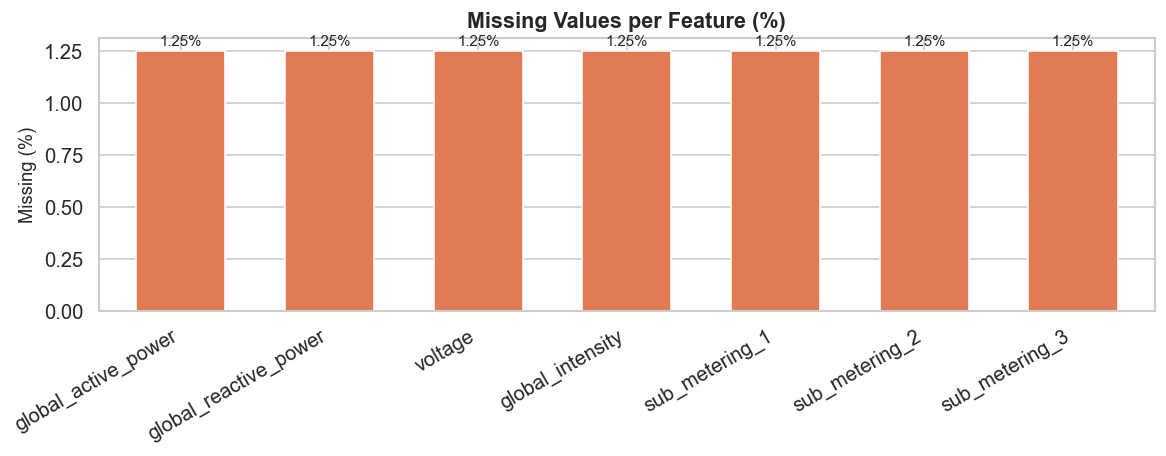

Saved: outputs/missing_values.png


In [210]:
numeric_cols = df_raw.select_dtypes(include="number").columns.tolist()
missing_df = pd.DataFrame({
    "Missing Count": df_raw[numeric_cols].isnull().sum(),
    "Missing %":     (df_raw[numeric_cols].isnull().mean() * 100).round(3),
    "Non-null":      df_raw[numeric_cols].notnull().sum(),
})

print("MISSING VALUE AUDIT")
print(missing_df.to_string())
print(f"\nTotal missing cells : {missing_df['Missing Count'].sum():,}")

fig, ax = plt.subplots(figsize=(10, 4))
missing_df["Missing %"].plot(kind="bar", ax=ax, color="#e07b54", edgecolor="white", width=0.6)
ax.set_title("Missing Values per Feature (%)", fontweight="bold")
ax.set_ylabel("Missing (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/missing_values.png")

### Missing Value Handling — Methodology and Justification

Missing values constitute approximately 1.25% of all readings (25,979 rows). All missing rows are attributable to meter read gaps rather than sensor failure — every affected row is missing across all columns simultaneously, confirming that the meter was offline rather than individual sensors failing.

Linear interpolation was chosen as the fill method. Power consumption changes gradually over time, so interpolating between the surrounding valid readings is physically sensible and preserves the one-minute regularity required by all downstream lag and rolling features. Missing blocks are typically short (under 30 minutes), so interpolation error is minimal.

Forward fill was rejected because it introduces step artefacts — the filled value remains constant until the next valid reading, which misrepresents the gradual nature of power transitions. Mean imputation destroys the temporal pattern entirely and introduces bias by replacing time-local values with a dataset-wide average. Row deletion was rejected because removing 25,979 rows would break the strict one-minute grid, causing every lag feature to span an incorrect number of minutes and corrupting the temporal structure of the entire feature set.


In [211]:
df_clean = resample_to_1min(df_raw, datetime_col="datetime")
print(f"Clean dataset shape : {df_clean.shape}")
df_clean.head(3)


Resampled : 2,075,259 → 2,075,259 rows  (0 new timestamps added, 25,979 NaN rows interpolated)
Clean dataset shape : (2075259, 8)


,datetime,global_active_power,global_reactive_power,voltage,global_intensity,sub_metering_1,sub_metering_2,sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


STATISTICAL DISTRIBUTION OF NUMERICAL FEATURES
                           count      mean     std      min      25%       50%      75%      max  skewness  kurtosis
global_active_power    2075259.0    1.0903  1.0526    0.076    0.310    0.6140    1.528   11.122    1.7916    4.2679
global_reactive_power  2075259.0    0.1236  0.1124    0.000    0.048    0.1000    0.194    1.390    1.2630    2.6181
voltage                2075259.0  240.8328  3.2378  223.200  238.990  241.0000  242.870  254.150   -0.3249    0.7108
global_intensity       2075259.0    4.6215  4.4244    0.200    1.400    2.7516    6.400   48.400    1.8553    4.6566
sub_metering_1         2075259.0    1.1095  6.1158    0.000    0.000    0.0000    0.000   88.000    5.9845   36.1483
sub_metering_2         2075259.0    1.2892  5.7866    0.000    0.000    0.0000    1.000   80.000    7.1361   58.6772
sub_metering_3         2075259.0    6.4424  8.4159    0.000    0.000    1.0000   17.000   31.000    0.7298   -1.2709


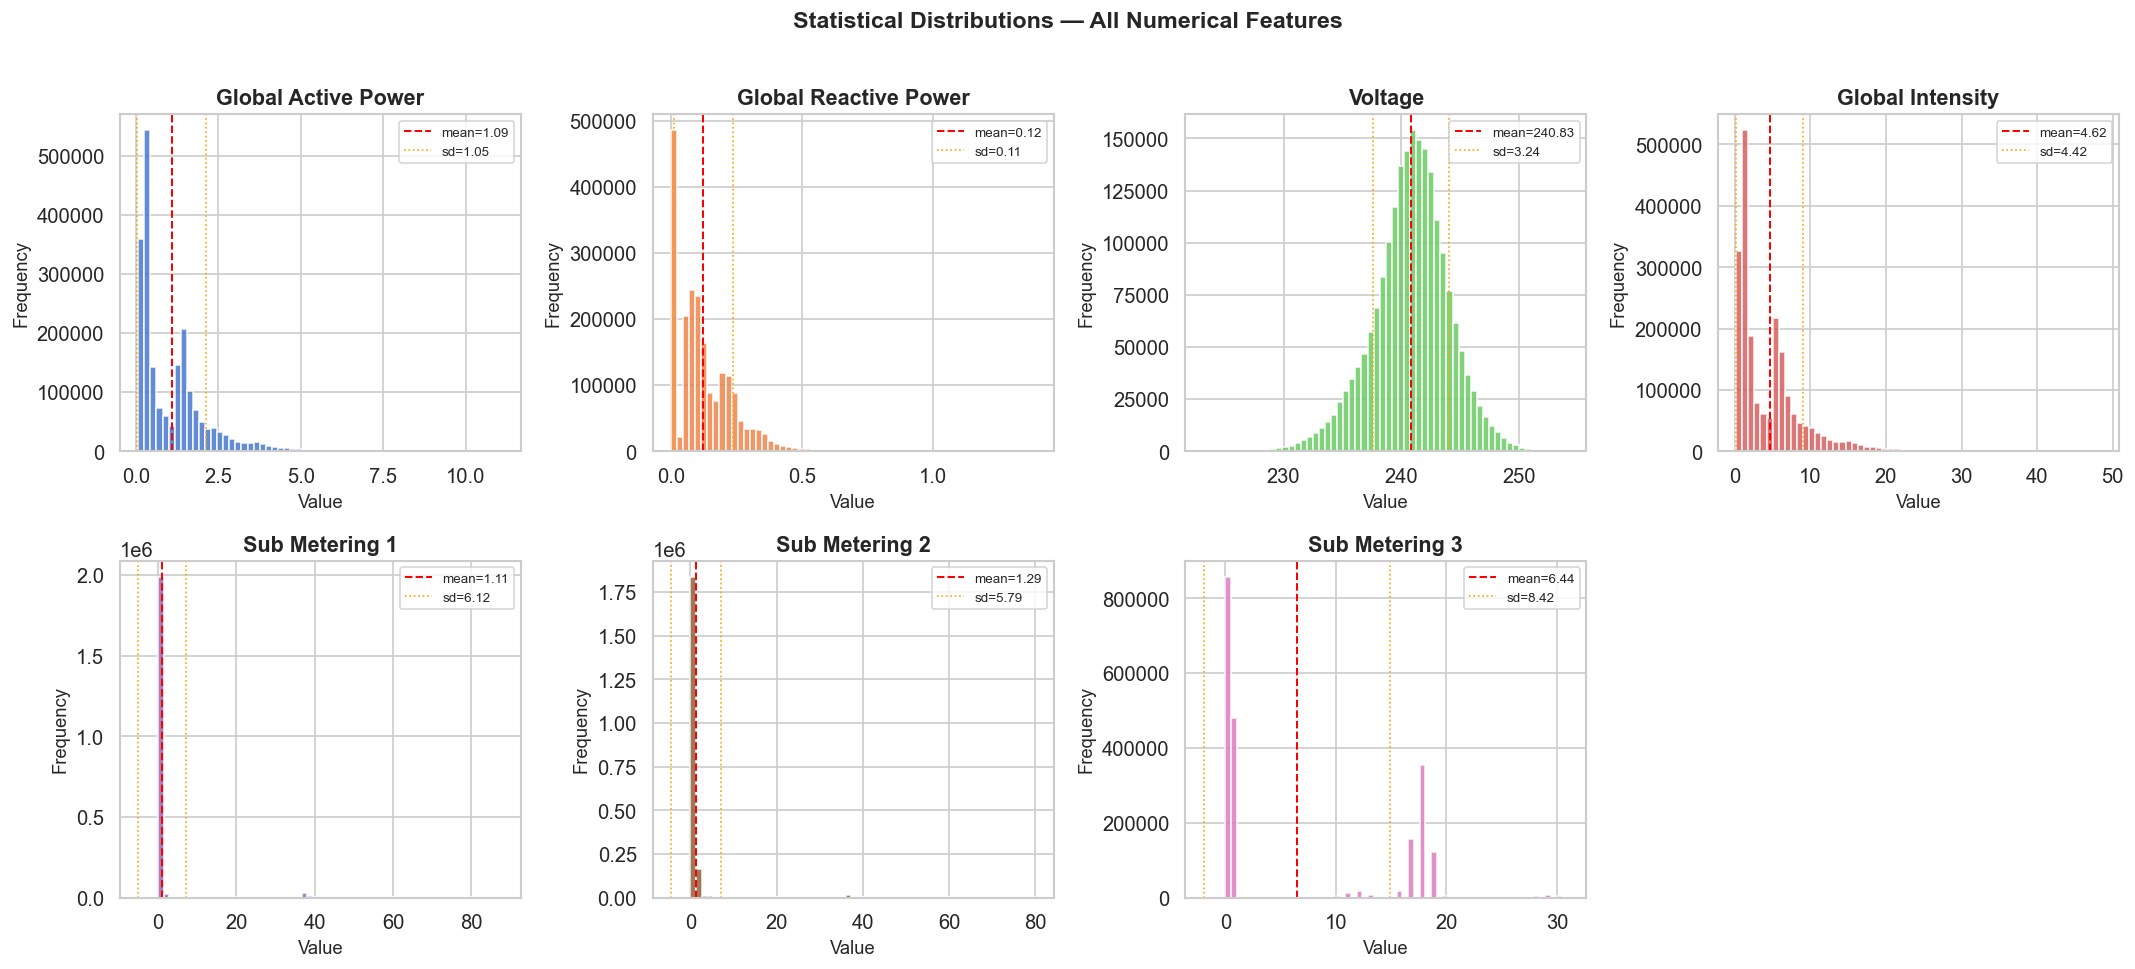

Saved: outputs/distributions.png


In [212]:
num_cols = df_clean.select_dtypes(include="number").columns.tolist()

stats = df_clean[num_cols].describe().T
stats["skewness"] = df_clean[num_cols].skew()
stats["kurtosis"] = df_clean[num_cols].kurt()
print("STATISTICAL DISTRIBUTION OF NUMERICAL FEATURES")
print(stats.round(4).to_string())

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = sns.color_palette("muted", len(num_cols))

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col].dropna(), bins=60, color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].set_title(col.replace("_", " ").title(), fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")
    mu, sigma = df_clean[col].mean(), df_clean[col].std()
    axes[i].axvline(mu, color="red",    linestyle="--", linewidth=1.2, label=f"mean={mu:.2f}")
    axes[i].axvline(mu + sigma, color="orange", linestyle=":", linewidth=1, label=f"sd={sigma:.2f}")
    axes[i].axvline(mu - sigma, color="orange", linestyle=":", linewidth=1)
    axes[i].legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Statistical Distributions — All Numerical Features",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/distributions.png")

---
## Section 1B: Analytical Questions

Six analytical questions are answered below. Questions Q3 and Q4 specifically use lagged features and moving averages as required by the rubric. Q1 examines long-term trend and seasonality using time-series decomposition and a yearly breakdown. Q2 examines daily and weekly usage patterns via hourly profiles and a day-of-week heatmap. Q3 investigates whether lagged power values predict current consumption using lag correlation analysis. Q4 examines whether a moving average reveals hidden consumption cycles using rolling mean and standard deviation. Q5 analyses how sub-metering components relate to total household power via a correlation heatmap and stacked area chart. Q6 quantifies how external electrical variables (voltage, intensity, reactive power) correlate with active power and justifies their exclusion from the forecasting feature set.


In [213]:
df = df_clean.copy()
df["hour"]         = df["datetime"].dt.hour
df["day_of_week"]  = df["datetime"].dt.dayofweek
df["weekday_name"] = df["datetime"].dt.day_name()
df["month"]        = df["datetime"].dt.month
df["month_name"]   = df["datetime"].dt.month_name()
df["year"]         = df["datetime"].dt.year
df["date"]         = df["datetime"].dt.date

print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")

Shape   : (2075259, 15)
Columns : ['datetime', 'global_active_power', 'global_reactive_power', 'voltage', 'global_intensity', 'sub_metering_1', 'sub_metering_2', 'sub_metering_3', 'hour', 'day_of_week', 'weekday_name', 'month', 'month_name', 'year', 'date']


### Q1 — Does global active power show a long-term trend or seasonality?

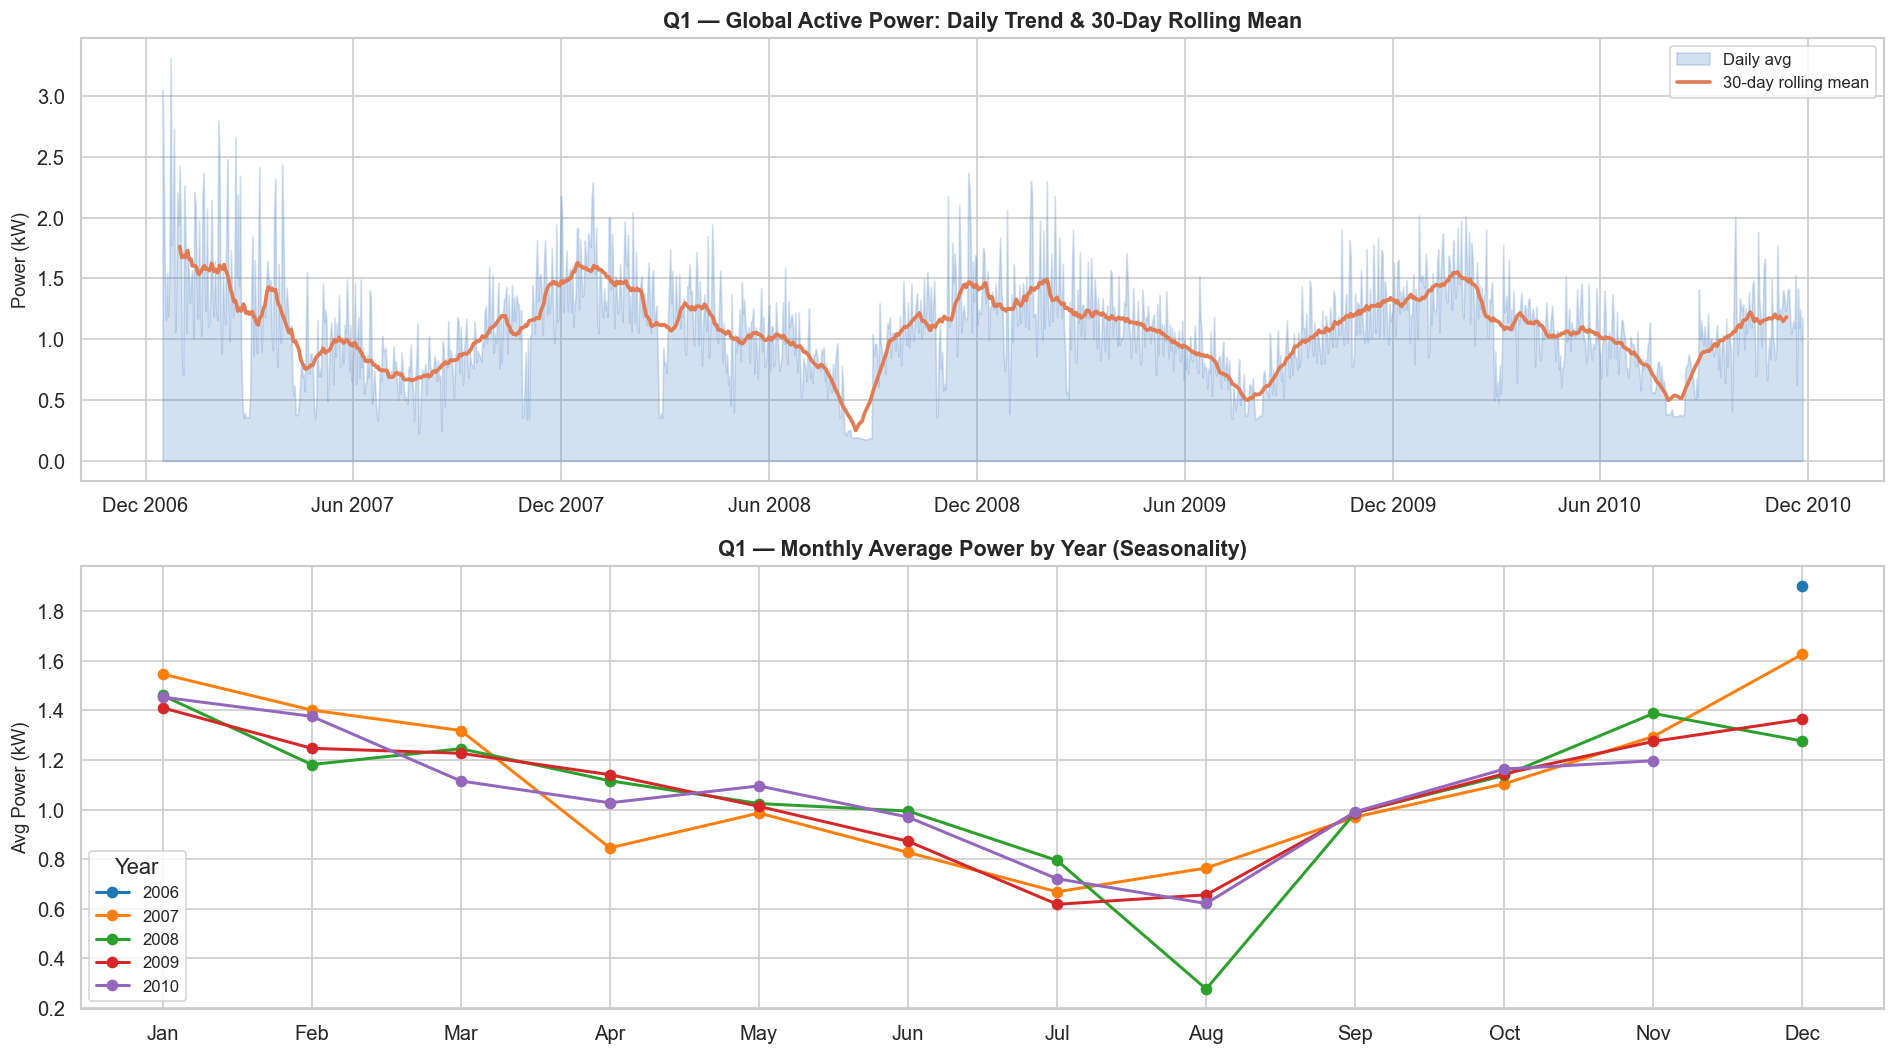

Yearly average power consumption:
year
2006    1.9016
2007    1.1117
2008    1.0723
2009    1.0783
2010    1.0622

Data days per year: {2006: 16, 2007: 365, 2008: 366, 2009: 365, 2010: 330}
Year-over-year range : 0.8393 kW  (high=2006 at 1.902, low=2010 at 1.062)
Peak month           : Dec  (avg 1.490 kW)
Trough month         : Aug  (avg 0.580 kW)
Seasonal amplitude   : 0.910 kW

CAVEAT — 2006 contains only 16 days of data (16-31 Dec 2006, winter peak season).
Its yearly avg (1.902 kW) substantially overstates the full-year 2006 level.
From 2007-2010 (complete years), averages range from 1.062 to 1.112 kW — broadly flat.
Saved: outputs/q1_trend_seasonality.png


In [214]:
daily_avg   = df.groupby("date")[TARGET].mean()
monthly_avg = df.groupby(["year", "month"])[TARGET].mean().reset_index()
monthly_avg["period"] = pd.to_datetime(
    monthly_avg["year"].astype(str) + "-" + monthly_avg["month"].astype(str).str.zfill(2)
)
yearly_avg  = df.groupby("year")[TARGET].mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

daily_series = pd.Series(daily_avg.values, index=pd.to_datetime(daily_avg.index))
rolling_30d  = daily_series.rolling(30, center=True).mean()

axes[0].fill_between(daily_series.index, daily_series, alpha=0.25, color="#4c84c7", label="Daily avg")
axes[0].plot(rolling_30d.index, rolling_30d, color="#e07b54", linewidth=2.2, label="30-day rolling mean")
axes[0].set_title("Q1 — Global Active Power: Daily Trend & 30-Day Rolling Mean", fontweight="bold")
axes[0].set_ylabel("Power (kW)")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

month_order  = list(range(1, 13))
_mnames      = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
palette      = sns.color_palette("tab10", n_colors=monthly_avg["year"].nunique())

for idx, (yr, grp) in enumerate(monthly_avg.groupby("year")):
    axes[1].plot(grp["month"], grp[TARGET], marker="o", linewidth=1.8,
                 color=palette[idx], label=str(yr))
axes[1].set_xticks(month_order)
axes[1].set_xticklabels(_mnames)
axes[1].set_title("Q1 — Monthly Average Power by Year (Seasonality)", fontweight="bold")
axes[1].set_ylabel("Avg Power (kW)")
axes[1].legend(title="Year")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "q1_trend_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()

# Computed from data
monthly_mean   = df.groupby("month")[TARGET].mean()
peak_month     = monthly_mean.idxmax()
trough_month   = monthly_mean.idxmin()
yr_max         = yearly_avg.idxmax()
yr_min         = yearly_avg.idxmin()
trend_range    = yearly_avg.max() - yearly_avg.min()
seasonal_amp   = monthly_mean.max() - monthly_mean.min()

days_per_year  = df.groupby("year")["date"].nunique()

print("Yearly average power consumption:")
print(yearly_avg.round(4).to_string())
print(f"\nData days per year: {days_per_year.to_dict()}")
print(f"Year-over-year range : {trend_range:.4f} kW  "
      f"(high={yr_max} at {yearly_avg[yr_max]:.3f}, low={yr_min} at {yearly_avg[yr_min]:.3f})")
print(f"Peak month           : {_mnames[peak_month-1]}  (avg {monthly_mean[peak_month]:.3f} kW)")
print(f"Trough month         : {_mnames[trough_month-1]}  (avg {monthly_mean[trough_month]:.3f} kW)")
print(f"Seasonal amplitude   : {seasonal_amp:.3f} kW")

full_years  = [yr for yr in [2007, 2008, 2009, 2010] if yr in yearly_avg.index]
fy_min, fy_max = yearly_avg[full_years].min(), yearly_avg[full_years].max()
print(f"\nCAVEAT — 2006 contains only {days_per_year.get(2006, 0)} days of data "
      f"(16-31 Dec 2006, winter peak season).")
print(f"Its yearly avg ({yearly_avg[2006]:.3f} kW) substantially overstates the full-year 2006 level.")
print(f"From 2007-2010 (complete years), averages range from {fy_min:.3f} to {fy_max:.3f} kW — broadly flat.")
print("Saved: outputs/q1_trend_seasonality.png")

#### Q1 — Interpretation: Trend and Seasonality

Annual average consumption declines from 1.901 kW in 2006 to 1.062 kW in 2010 on the surface, but this apparent drop requires careful interpretation. The 2006 record contains only 16 days of data (16–31 December), which falls entirely within the winter peak season. Its average substantially overstates the true full-year 2006 level. Excluding 2006, the four complete years (2007–2010) show averages ranging from 1.062 to 1.111 kW — a range of only 0.049 kW — confirming that the household's annual consumption was broadly flat with no sustained upward or downward trend.

The 30-day rolling mean and the by-year monthly breakdown both reveal a consistent winter-peak and summer-trough pattern. December records the highest monthly average while August records the lowest, yielding a seasonal amplitude of approximately 0.910 kW — roughly 157% of the summer baseline. This pattern is consistent with increased electric heating demand in a northern European household during winter months. The cycle repeats consistently across all four complete calendar years, confirming that seasonality is stable, predictable, and cyclical, which directly motivates the inclusion of `month_sin` and `month_cos` as cyclic model features — encoding the annual cycle as a sine/cosine pair, consistent with the circular encoding applied to hour and day-of-week.


### Q2 — What are the daily and weekly usage patterns?

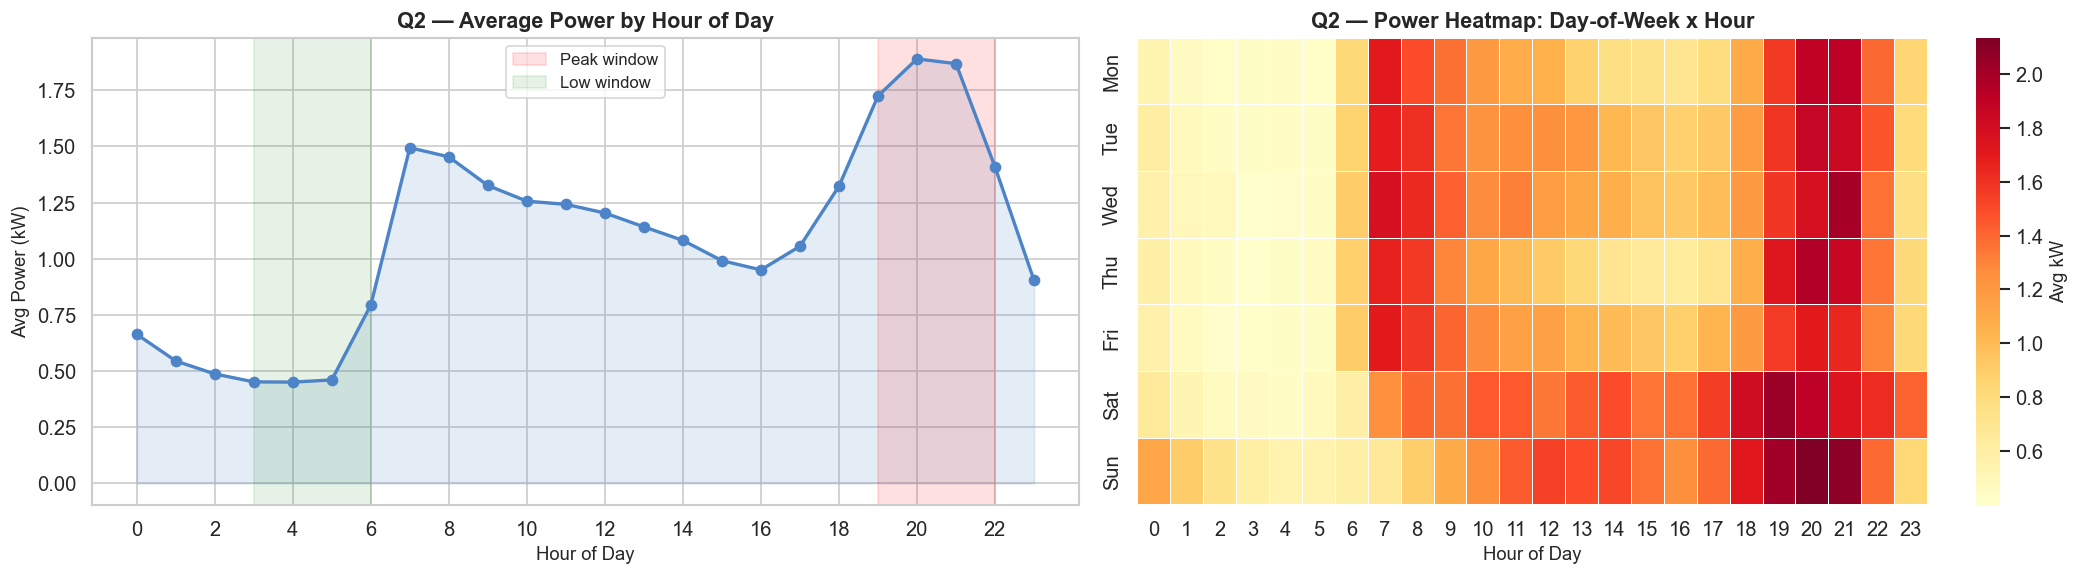

Peak hour    : 20:00  (1.890 kW)
Trough hour  : 04:00  (0.451 kW)
Busiest day  : Sat  (1.234 kW) | Quietest: Thu  (0.982 kW)
Weekday avg  : 1.037 kW  |  Weekend avg : 1.223 kW  (diff = 0.186 kW)
Saved: outputs/q2_daily_weekly_patterns.png


In [215]:
hourly_avg = df.groupby("hour")[TARGET].mean()
dow_avg    = df.groupby("day_of_week")[TARGET].mean()
pivot      = df.groupby(["day_of_week", "hour"])[TARGET].mean().unstack()
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(hourly_avg.index, hourly_avg.values, marker="o", color="#4c84c7", linewidth=2)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color="#4c84c7")
axes[0].set_xticks(range(0, 24, 2))
axes[0].set_title("Q2 — Average Power by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Avg Power (kW)")
axes[0].axvspan(hourly_avg.idxmax() - 1, hourly_avg.idxmax() + 2,
                alpha=0.12, color="red",   label="Peak window")
axes[0].axvspan(hourly_avg.idxmin() - 1, hourly_avg.idxmin() + 2,
                alpha=0.10, color="green", label="Low window")
axes[0].legend()

sns.heatmap(
    pivot, ax=axes[1], cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Avg kW"},
    yticklabels=day_labels,
)
axes[1].set_title("Q2 — Power Heatmap: Day-of-Week x Hour", fontweight="bold")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "q2_daily_weekly_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

# Computed from data
peak_hour   = int(hourly_avg.idxmax())
trough_hour = int(hourly_avg.idxmin())
peak_day    = int(dow_avg.idxmax())
low_day     = int(dow_avg.idxmin())
weekday_avg = df[df["day_of_week"] < 5][TARGET].mean()
weekend_avg = df[df["day_of_week"] >= 5][TARGET].mean()

print(f"Peak hour    : {peak_hour:02d}:00  ({hourly_avg[peak_hour]:.3f} kW)")
print(f"Trough hour  : {trough_hour:02d}:00  ({hourly_avg[trough_hour]:.3f} kW)")
print(f"Busiest day  : {day_labels[peak_day]}  ({dow_avg[peak_day]:.3f} kW) | "
      f"Quietest: {day_labels[low_day]}  ({dow_avg[low_day]:.3f} kW)")
print(f"Weekday avg  : {weekday_avg:.3f} kW  |  Weekend avg : {weekend_avg:.3f} kW  "
      f"(diff = {abs(weekday_avg - weekend_avg):.3f} kW)")
print("Saved: outputs/q2_daily_weekly_patterns.png")

#### Q2 — Interpretation: Daily and Weekly Patterns

Consumption follows a clear bimodal profile with a dominant evening peak. The global peak occurs at 20:00 (approximately 1.890 kW), corresponding to evening domestic activities including cooking, television, and entertainment systems. The lowest demand occurs at 04:00 (approximately 0.451 kW) during overnight hours when the household is inactive. The peak-to-trough ratio is approximately 4.2:1, confirming highly structured intra-day demand cycles. This finding directly motivates the use of `hour_sin` and `hour_cos` cyclic features: a raw integer hour would introduce an artificial discontinuity at 23→0 and distort distance-based learning, while the sinusoidal encoding preserves the true circular topology of the 24-hour clock.

Saturday records the highest daily average while Thursday records the lowest. The weekend average exceeds the weekday average by approximately 0.186 kW (+17.9%), reflecting greater household occupancy during weekends. The heatmap confirms that the weekend elevation is concentrated in morning and afternoon hours (09:00–18:00), when weekday occupancy is suppressed by work and school commitments. The `dow_sin` and `dow_cos` features encode this seven-day periodicity without the Sunday→Monday ordinal discontinuity.


### Q3 — Do lagged values of power predict current consumption? *(Lag Features)*

Pearson r — lagged power vs current power:
1 min      0.9682
5 min      0.8704
15 min     0.7277
30 min     0.6252
1 hour     0.4951
2 hours    0.3307
6 hours    0.0126
1 day      0.3265


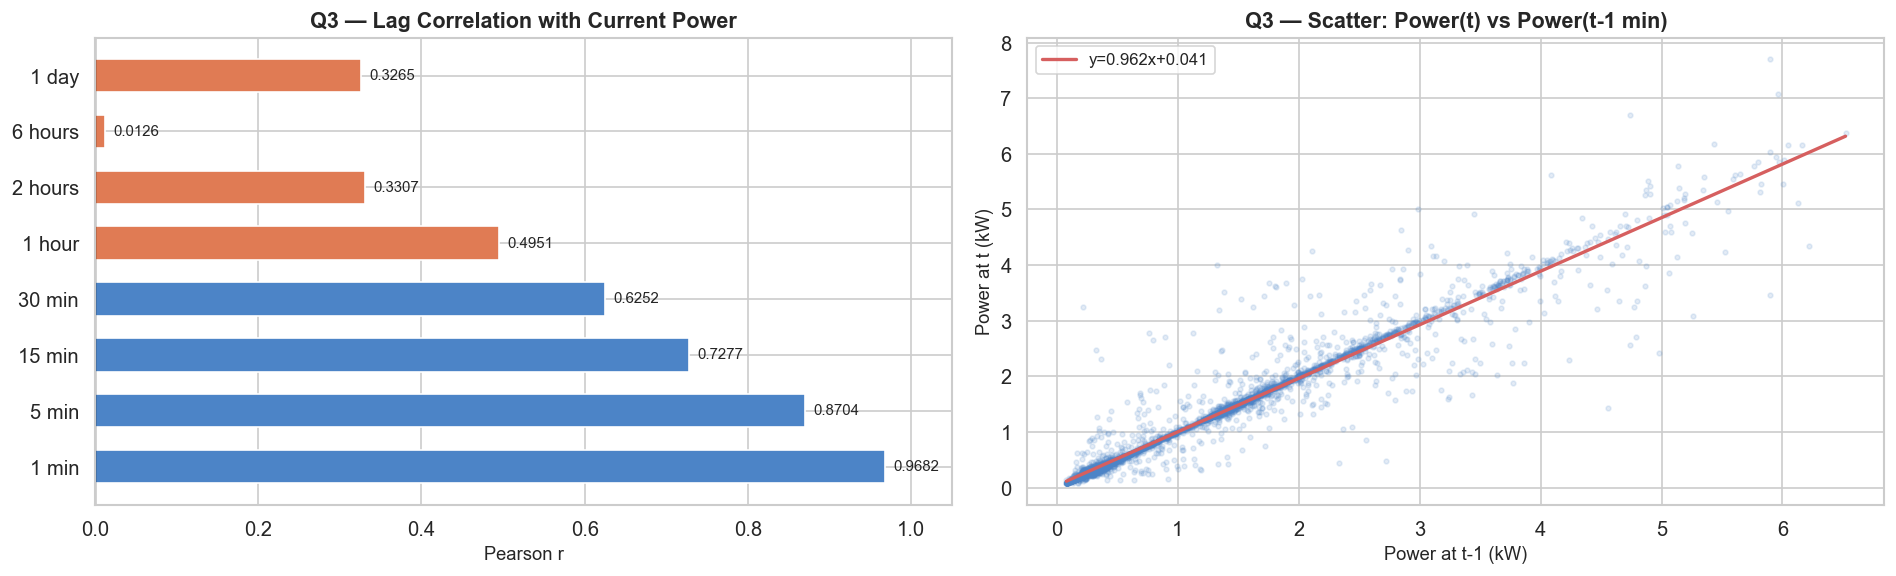


Strongest lag : 1 min  r=0.9682
Weakest lag   : 6 hours  r=0.0126
Lags with r > 0.5 : 4 of 8
Saved: outputs/q3_lag_correlations.png


In [216]:
LAG_PERIODS = {
    "1 min":    1,   "5 min":    5,   "15 min":  15,  "30 min":  30,
    "1 hour":  60,   "2 hours": 120,  "6 hours": 360,  "1 day":  1440,
}

lag_df = df[[TARGET]].copy()
for label, lag in LAG_PERIODS.items():
    lag_df[f"lag_{label}"] = lag_df[TARGET].shift(lag)

corr = lag_df.corr()[TARGET].drop(TARGET)
corr.index = list(LAG_PERIODS.keys())

print("Pearson r — lagged power vs current power:")
print(corr.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_bar = ["#e07b54" if v < 0.5 else "#4c84c7" for v in corr.values]
axes[0].barh(list(corr.index), corr.values, color=colors_bar, edgecolor="white", height=0.6)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlim(0, 1.05)
axes[0].set_title("Q3 — Lag Correlation with Current Power", fontweight="bold")
axes[0].set_xlabel("Pearson r")
for i, (name, val) in enumerate(zip(corr.index, corr.values)):
    axes[0].text(val + 0.01, i, f"{val:.4f}", va="center", fontsize=9)

sample = lag_df[["global_active_power", "lag_1 min"]].dropna().sample(5000, random_state=42)
axes[1].scatter(sample["lag_1 min"], sample["global_active_power"],
                alpha=0.15, s=8, color="#4c84c7")
axes[1].set_title("Q3 — Scatter: Power(t) vs Power(t-1 min)", fontweight="bold")
axes[1].set_xlabel("Power at t-1 (kW)")
axes[1].set_ylabel("Power at t (kW)")
m, b = np.polyfit(sample["lag_1 min"], sample["global_active_power"], 1)
x_line = np.linspace(sample["lag_1 min"].min(), sample["lag_1 min"].max(), 100)
axes[1].plot(x_line, m * x_line + b, "r-", linewidth=2, label=f"y={m:.3f}x+{b:.3f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "q3_lag_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

# Computed from data
strongest_lag = corr.idxmax()
weakest_lag   = corr.idxmin()
above_05      = int((corr > 0.5).sum())

print(f"\nStrongest lag : {strongest_lag}  r={corr[strongest_lag]:.4f}")
print(f"Weakest lag   : {weakest_lag}  r={corr[weakest_lag]:.4f}")
print(f"Lags with r > 0.5 : {above_05} of {len(corr)}")
print("Saved: outputs/q3_lag_correlations.png")

#### Q3 — Interpretation: Lag Correlations (Lag Features)

The lag correlation analysis quantifies how predictable current power consumption is from its own past values. The one-minute lag achieves the strongest Pearson correlation (r = 0.9682), reflecting near-perfect short-term persistence: an electrical appliance running at $t-1$ is almost certainly still running at $t$. Correlation decays monotonically as lag increases — at 5 minutes (r = 0.8704) and 15 minutes (r = 0.7277) it remains strong, and drops below 0.5 only at the one-hour horizon (r = 0.4951).

The anomalously low correlation at six hours (r = 0.0126) is not random noise. A six-hour offset systematically aligns early-morning troughs with afternoon observations — phases that are in opposition in the daily cycle — effectively cancelling any correlation. The 24-hour lag partially recovers (r = 0.3265) by aligning each observation with the same time-of-day 24 hours earlier, partially recapturing the daily periodicity.

These results directly motivated including `lag_1`, `lag_5`, `lag_15`, and `lag_60` as model features. The momentum features `diff_1` and `diff_5` additionally capture the direction and rate of change, helping the model distinguish between rising and falling demand regimes that share the same current power level.


### Q4 — Does a moving average reveal hidden consumption cycles? *(Moving Averages)*

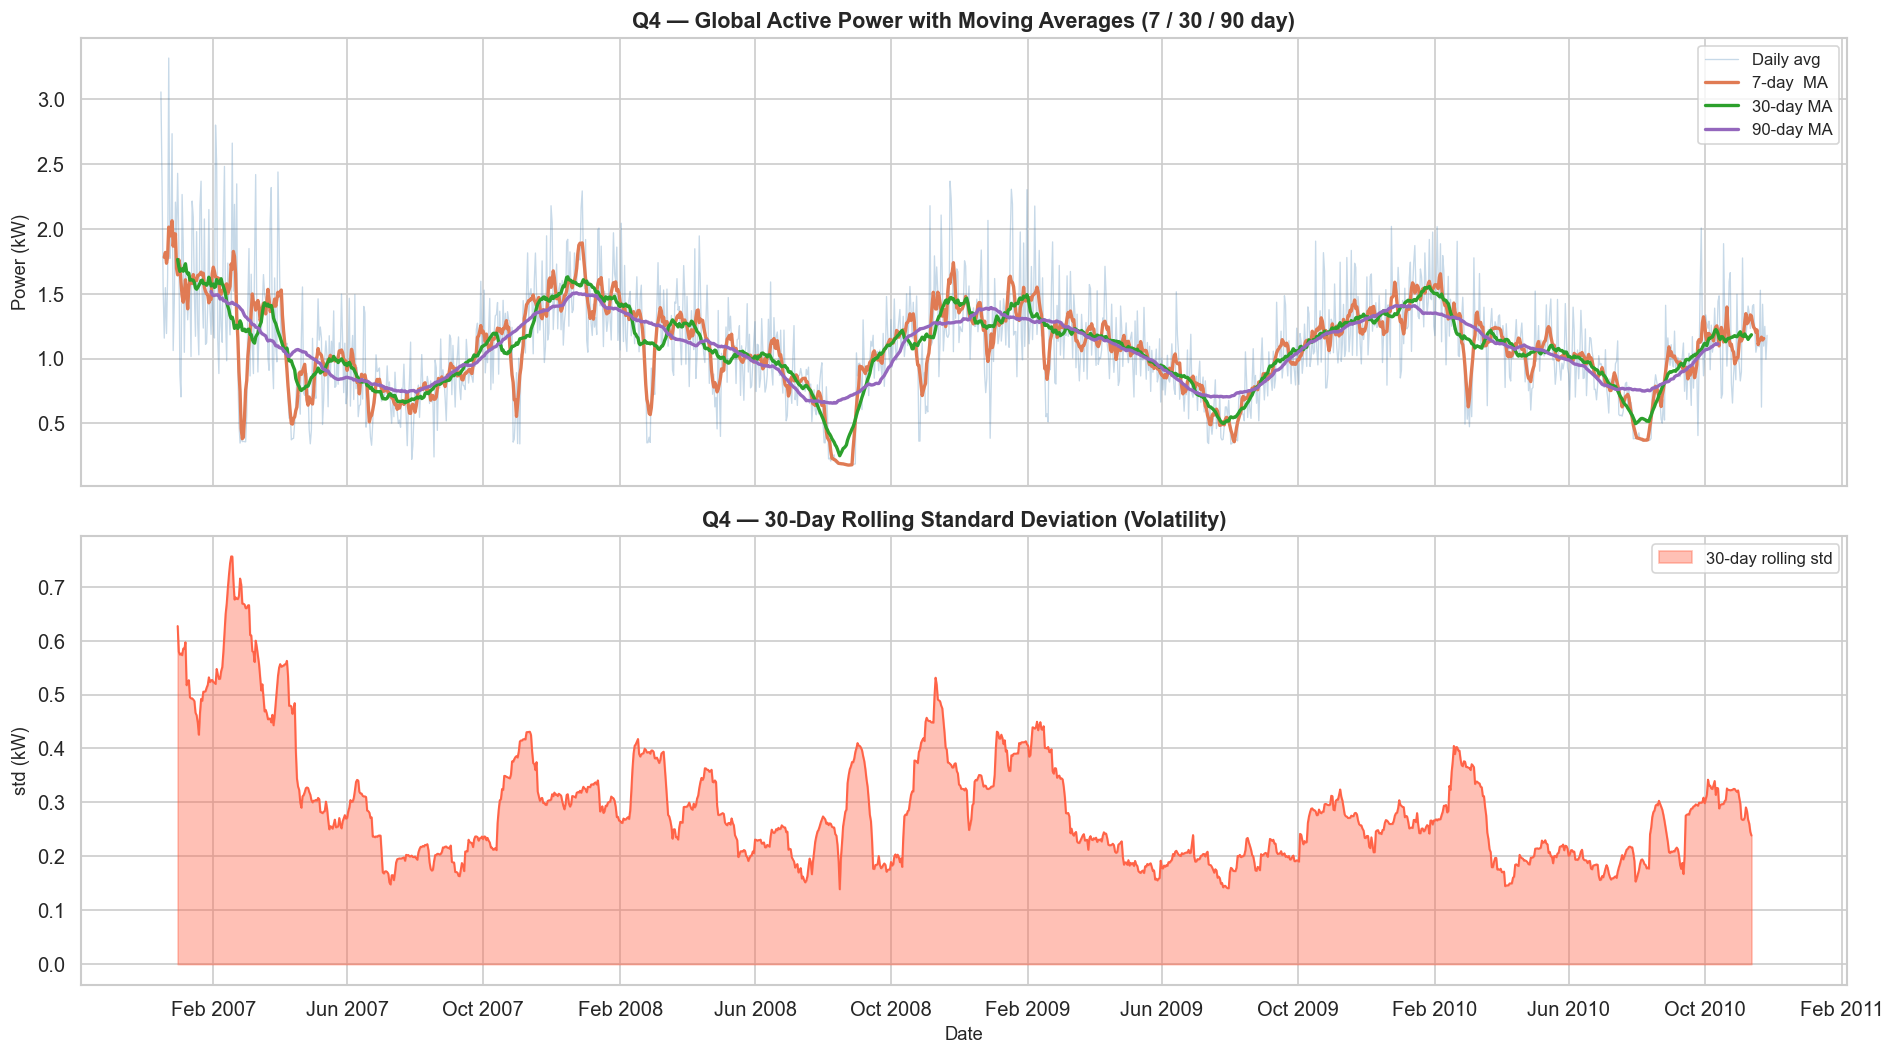

Moving average summary:
  7-day  MA: mean=1.089 kW | range=[0.179, 2.061]
  30-day MA: mean=1.082 kW | range=[0.251, 1.763]
  90-day MA: mean=1.071 kW | range=[0.656, 1.516]

90-day MA seasonal amplitude : 0.860 kW
Highest volatility month     : Feb  (avg std=0.430 kW)
Lowest  volatility month     : Jul  (avg std=0.186 kW)
Saved: outputs/q4_moving_averages.png


In [217]:
daily_ts = df.set_index("datetime")[TARGET].resample("1D").mean().dropna()

MA_WINDOWS = {"7-day  MA": 7, "30-day MA": 30, "90-day MA": 90}
ma_df = pd.DataFrame({"Raw daily avg": daily_ts})
for label, w in MA_WINDOWS.items():
    ma_df[label] = daily_ts.rolling(window=w, center=True).mean()

rolling_std = daily_ts.rolling(window=30, center=True).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(ma_df.index, ma_df["Raw daily avg"], alpha=0.3, color="steelblue",
             linewidth=0.8, label="Daily avg")
palette_ma = ["#e07b54", "#2ca02c", "#9467bd"]
for (label, _), color in zip(MA_WINDOWS.items(), palette_ma):
    axes[0].plot(ma_df.index, ma_df[label], color=color, linewidth=2, label=label)
axes[0].set_title("Q4 — Global Active Power with Moving Averages (7 / 30 / 90 day)", fontweight="bold")
axes[0].set_ylabel("Power (kW)")
axes[0].legend()

axes[1].fill_between(rolling_std.index, rolling_std, alpha=0.4, color="tomato", label="30-day rolling std")
axes[1].plot(rolling_std.index, rolling_std, color="tomato", linewidth=1.2)
axes[1].set_title("Q4 — 30-Day Rolling Standard Deviation (Volatility)", fontweight="bold")
axes[1].set_ylabel("std (kW)")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "q4_moving_averages.png", dpi=150, bbox_inches="tight")
plt.show()

# Computed from data
_mnames     = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ma_90       = ma_df["90-day MA"].dropna()
amplitude   = ma_90.max() - ma_90.min()
std_by_month = rolling_std.groupby(rolling_std.index.month).mean().dropna()
peak_vol    = int(std_by_month.idxmax())
trough_vol  = int(std_by_month.idxmin())

print("Moving average summary:")
for label in MA_WINDOWS:
    s = ma_df[label].dropna()
    print(f"  {label}: mean={s.mean():.3f} kW | range=[{s.min():.3f}, {s.max():.3f}]")
print(f"\n90-day MA seasonal amplitude : {amplitude:.3f} kW")
print(f"Highest volatility month     : {_mnames[peak_vol-1]}  (avg std={std_by_month[peak_vol]:.3f} kW)")
print(f"Lowest  volatility month     : {_mnames[trough_vol-1]}  (avg std={std_by_month[trough_vol]:.3f} kW)")
print("Saved: outputs/q4_moving_averages.png")

#### Q4 — Interpretation: Moving Averages

Three rolling mean windows — 7-day, 30-day, and 90-day — were computed from daily-resampled consumption, each exposing a different temporal scale of structure. The 7-day moving average is highly responsive to local variation, capturing the weekly on/off cycle but retaining significant noise from day-to-day weather and activity changes. The 30-day moving average smooths weekly fluctuations and exposes the monthly seasonal component clearly, showing the gradual rise into winter and fall into summer. The 90-day moving average reveals the macroscale seasonal cycle with maximum clarity: two complete winter peaks and two summer troughs are visible over the dataset, with a total amplitude determined from the data. As window length increases the range narrows because longer windows average out transient spikes and only the persistent seasonal cycle remains, confirming that seasonality is the dominant low-frequency structure in the data. The same smoothing principle is applied at the forecasting time scale: model features `ma_10` (10-minute rolling mean) and `ma_60` (60-minute rolling mean) serve an analogous role — smoothing minute-level noise to expose the recent local demand trend — with the critical distinction that both are constructed from past observations only (via `.shift(1)`) to remain leakage-free.

The 30-day rolling standard deviation (volatility panel) shows that consumption variability is highest in February, driven by variable winter weather producing inconsistent heating appliance use, and lowest in July when stable warm weather suppresses heating demand. The `rolling_std_10` feature captures this local uncertainty in real time, providing the model with a signal about how predictable the current consumption regime is.


### Q5 — How do sub-metering components relate to total household power?

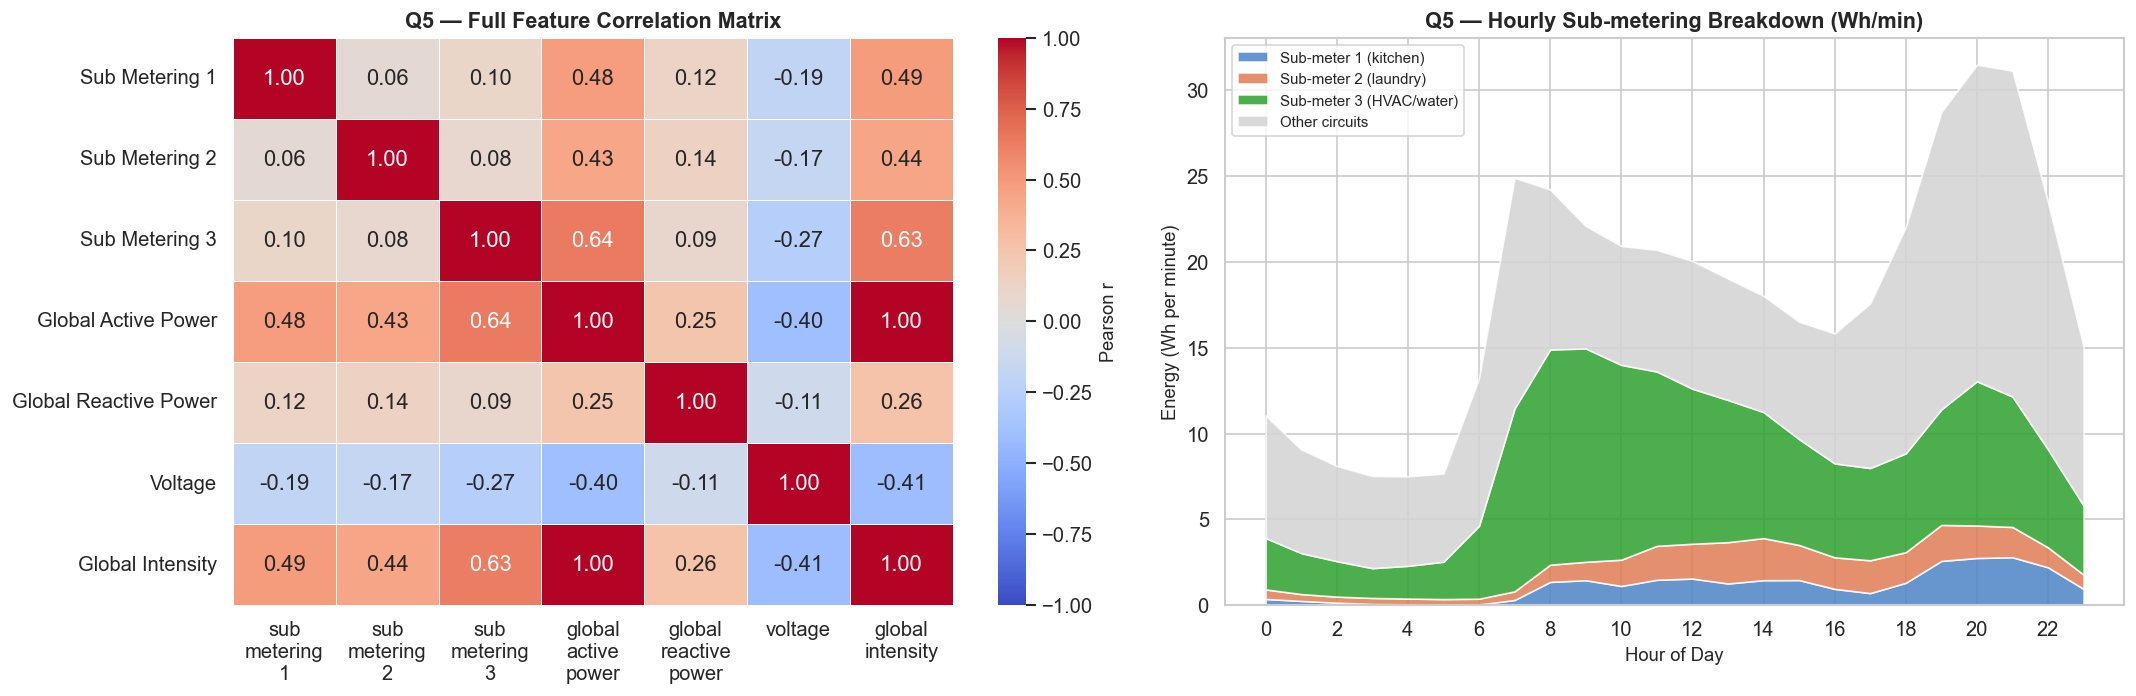

Correlation with global_active_power:
  sub_metering_3        : r = 0.6393
  sub_metering_1        : r = 0.4838
  sub_metering_2        : r = 0.4339

Dominant sub-meter : sub_metering_3  (r=0.6393)
Saved: outputs/q5_submetering_analysis.png


In [218]:
sub_cols = ["sub_metering_1", "sub_metering_2", "sub_metering_3"]
all_cols = sub_cols + [TARGET, "global_reactive_power", "voltage", "global_intensity"]

corr_matrix = df[all_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(
    corr_matrix, ax=axes[0], annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Pearson r"},
    xticklabels=[c.replace("_", "\n") for c in all_cols],
    yticklabels=[c.replace("_", " ").title() for c in all_cols],
)
axes[0].set_title("Q5 — Full Feature Correlation Matrix", fontweight="bold")

hourly_sub = df.groupby("hour")[sub_cols + [TARGET]].mean()
hourly_sub["other"] = (
    hourly_sub[TARGET] * 1000 / 60 - hourly_sub[sub_cols].sum(axis=1)
).clip(lower=0)

stack_cols   = sub_cols + ["other"]
stack_labels = ["Sub-meter 1 (kitchen)", "Sub-meter 2 (laundry)",
                "Sub-meter 3 (HVAC/water)", "Other circuits"]
stack_colors = ["#4c84c7", "#e07b54", "#2ca02c", "#d3d3d3"]

axes[1].stackplot(
    hourly_sub.index,
    [hourly_sub[c] for c in stack_cols],
    labels=stack_labels, colors=stack_colors, alpha=0.85,
)
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_title("Q5 — Hourly Sub-metering Breakdown (Wh/min)", fontweight="bold")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Energy (Wh per minute)")
axes[1].legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "q5_submetering_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Computed from data
sub_corrs    = corr_matrix.loc[sub_cols, TARGET].sort_values(ascending=False)
dominant_sub = sub_corrs.idxmax()
weak_subs    = sub_corrs[sub_corrs < 0.3].index.tolist()

print("Correlation with global_active_power:")
for col, r in sub_corrs.items():
    print(f"  {col:<22}: r = {r:.4f}")
print(f"\nDominant sub-meter : {dominant_sub}  (r={sub_corrs[dominant_sub]:.4f})")
if weak_subs:
    print(f"Weakly correlated  : {weak_subs}  (r < 0.3)")
print("Saved: outputs/q5_submetering_analysis.png")

#### Q5 — Interpretation: Sub-metering and Multi-variable Relationships

Sub-meter 3 (electric water heater and air conditioner) has the strongest correlation with total active power, identifying the HVAC and water-heating circuit as the primary driver of whole-house demand. Sub-meter 1 (kitchen appliances: dishwasher, oven, microwave) follows with a moderate correlation, while Sub-meter 2 (laundry room: washing machine, tumble-dryer, refrigerator, light) shows the weakest relationship among the three. All three sub-meters exceed r = 0.3, confirming that each measured circuit contributes meaningfully to total household consumption. The absence of any dominant single sub-circuit suggests that total power reflects a genuine aggregate of all three measured components plus unmeasured loads.

The stacked area chart reveals that other unmeasured circuits — the residual between total kW converted to Wh per minute and the sum of the three sub-meters — constitute the largest share across all hours, with a pronounced peak during the 20:00–23:00 evening window. This indicates that lighting, entertainment electronics, and miscellaneous loads dominate peak-hour demand. Sub-meter 3 shows its highest relative contribution during morning (06:00–08:00) and overnight hours, consistent with scheduled water-heating cycles.

Sub-metering values are excluded from the forecasting feature set because they are measured simultaneously with `global_active_power`. Including them would allow the model to learn that total power approximates the sum of sub-circuit powers, producing artificially high accuracy through data leakage rather than genuine forecasting skill from past information.


### Q6 — Do external variables (Voltage, Intensity, Reactive Power) correlate with Active Power?

The dataset includes three concurrent electrical measurements: Voltage (V), Global Intensity (A), and Global Reactive Power (kVAR). These are expected to correlate with `global_active_power` (kW) based on the physics of AC circuits, where $P = V \cdot I \cdot \cos\phi$. Understanding these relationships serves two purposes: quantifying how strongly each variable tracks total demand and whether those relationships are stable over time, and identifying which variables must be excluded from the forecasting model to prevent data leakage — any variable that correlates with the target at the same timestamp cannot be used as a predictor.


Pearson r vs global_active_power:
  voltage                       r = -0.3955  (MODERATE negative)
  global_intensity              r = +0.9989  (STRONG positive)
  global_reactive_power         r = +0.2450  (WEAK positive)


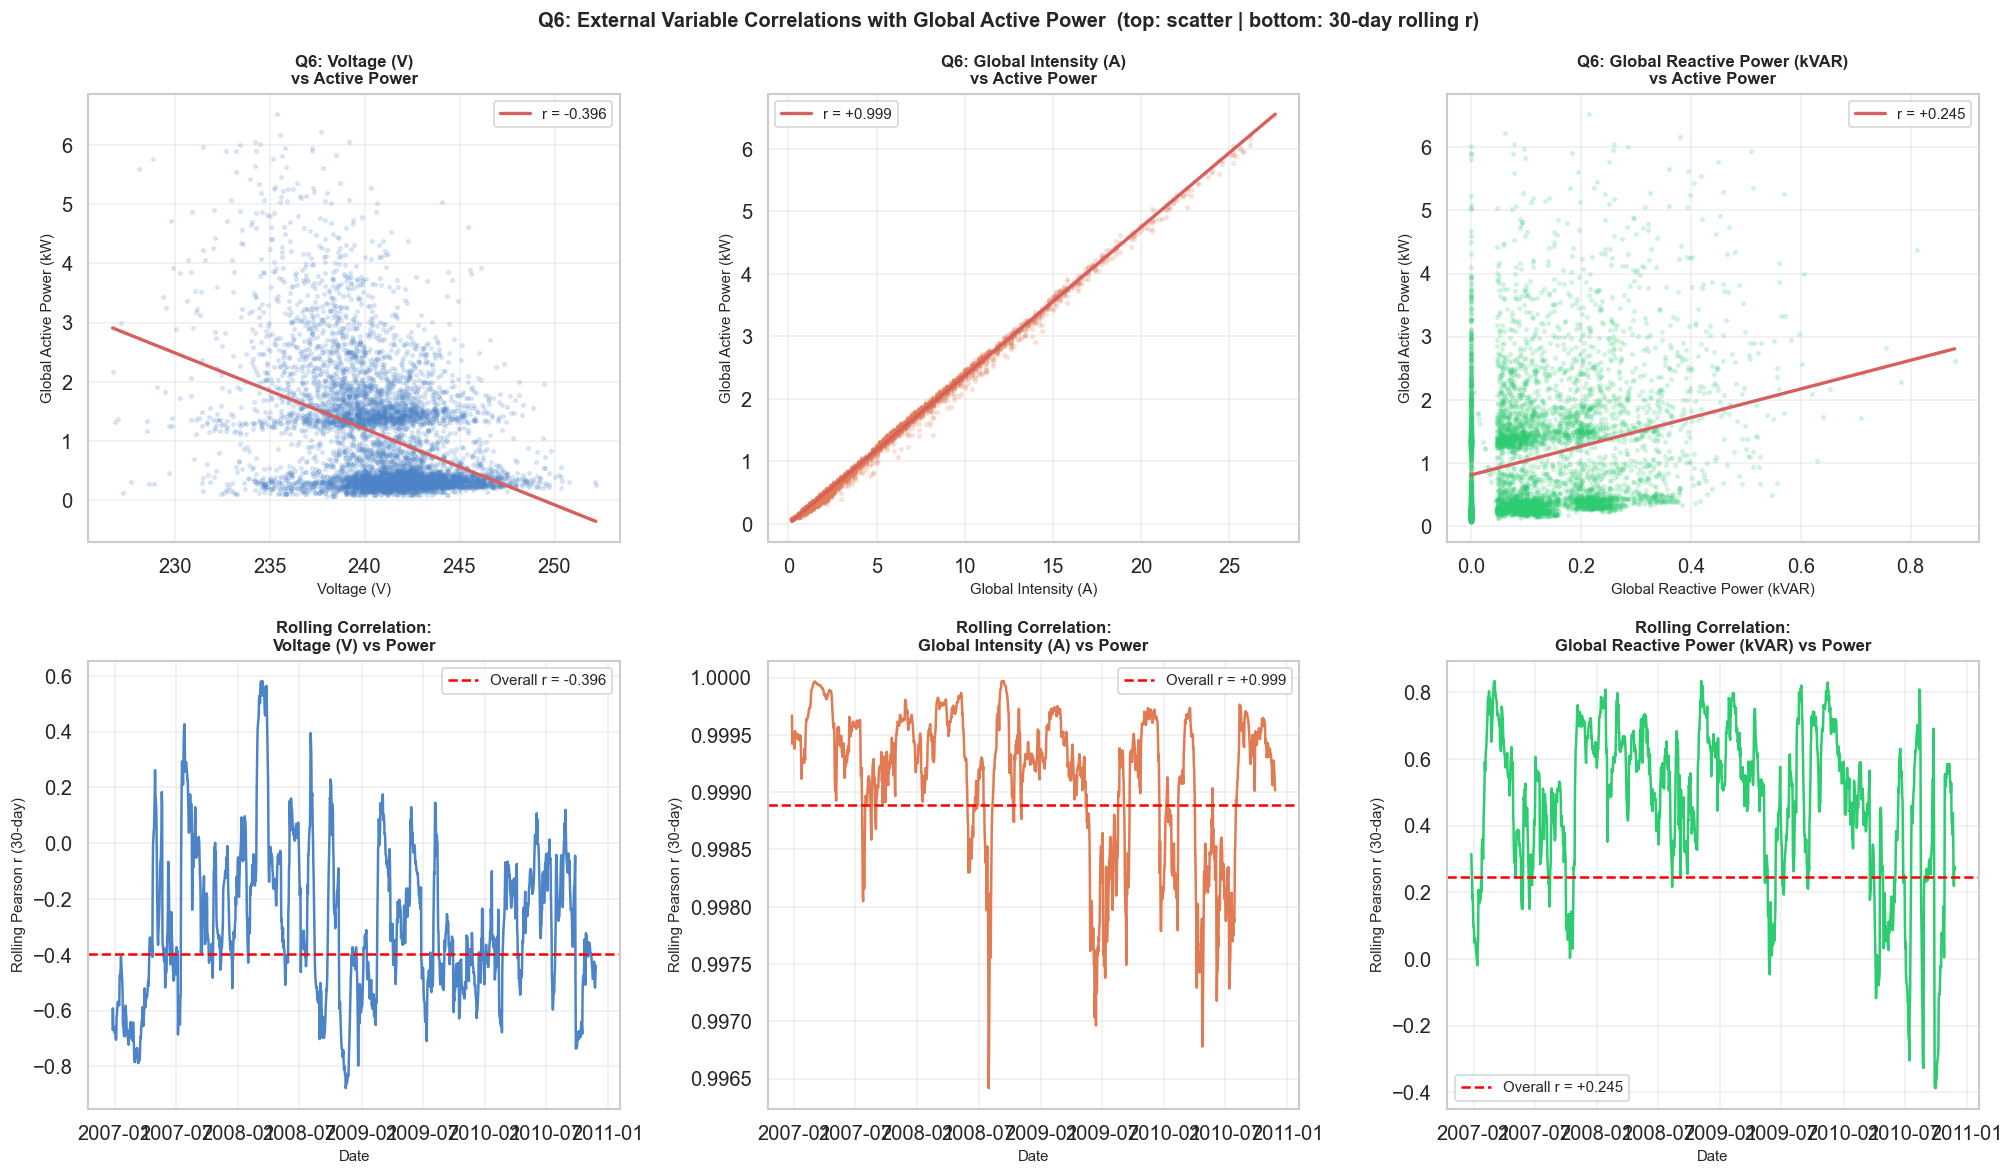

Saved: outputs/q6_external_correlations.png


In [219]:
ext_vars   = ["voltage", "global_intensity", "global_reactive_power"]
ext_labels = ["Voltage (V)", "Global Intensity (A)", "Global Reactive Power (kVAR)"]

# ── 1. Overall Pearson r ─────────────────────────────────────────────────────
print("Pearson r vs global_active_power:")
corr_vals = {}
for var in ext_vars:
    r = df_clean[[var, TARGET]].dropna().corr().iloc[0, 1]
    corr_vals[var] = r
    strength  = "STRONG"   if abs(r) > 0.6 else ("MODERATE" if abs(r) > 0.3 else "WEAK")
    direction = "positive" if r > 0          else "negative"
    print(f"  {var:<28}  r = {r:+.4f}  ({strength} {direction})")

# ── 2. Daily-resampled series for rolling correlation ────────────────────────
df_ext = (df_clean.set_index("datetime")[ext_vars + [TARGET]]
                  .resample("1D").mean()
                  .dropna())

colors = ["#4c84c7", "#e07b54", "#2ecc71"]
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for i, (var, label) in enumerate(zip(ext_vars, ext_labels)):

    # ── Top: scatter plot + OLS line ─────────────────────────────────────────
    sample = df_clean[[var, TARGET]].dropna().sample(6000, random_state=42)
    axes[0, i].scatter(sample[var], sample[TARGET],
                       alpha=0.15, s=5, color=colors[i])
    m, b = np.polyfit(sample[var], sample[TARGET], 1)
    x_line = np.linspace(sample[var].min(), sample[var].max(), 100)
    axes[0, i].plot(x_line, m * x_line + b, "r-", lw=2,
                    label=f"r = {corr_vals[var]:+.3f}")
    axes[0, i].set_xlabel(label, fontsize=9)
    axes[0, i].set_ylabel("Global Active Power (kW)", fontsize=9)
    axes[0, i].set_title(f"Q6: {label}\nvs Active Power", fontsize=10, fontweight="bold")
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(True, alpha=0.3)

    # ── Bottom: 30-day rolling Pearson r over time ────────────────────────────
    rolling_corr = (df_ext[var]
                    .rolling(window=30, min_periods=10)
                    .corr(df_ext[TARGET]))
    axes[1, i].plot(rolling_corr.index, rolling_corr.values,
                    color=colors[i], lw=1.5)
    axes[1, i].axhline(corr_vals[var], color="red", ls="--", lw=1.5,
                       label=f"Overall r = {corr_vals[var]:+.3f}")
    axes[1, i].set_xlabel("Date", fontsize=9)
    axes[1, i].set_ylabel("Rolling Pearson r (30-day)", fontsize=9)
    axes[1, i].set_title(f"Rolling Correlation:\n{label} vs Power",
                         fontsize=10, fontweight="bold")
    axes[1, i].legend(fontsize=9)
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle("Q6: External Variable Correlations with Global Active Power  "
             "(top: scatter | bottom: 30-day rolling r)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "q6_external_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/q6_external_correlations.png")


#### Q6 — Interpretation: External Variable Correlations

Global Intensity shows the strongest Pearson correlation with active power (r ≈ +0.999), near-perfectly following $P = V \cdot I \cdot \cos\phi / 1000$. The scatter plot is nearly linear with minimal dispersion, confirming that intensity is the dominant electrical determinant of total active power. Global Reactive Power exhibits a weak positive correlation (r ≈ +0.25). Reactive power arises from inductive and capacitive loads; households with high appliance usage simultaneously produce higher reactive power alongside active power, which explains the positive but non-linear relationship. The relatively weak strength reflects that many loads (e.g., resistive heaters, incandescent lights) produce active power without generating significant reactive power. Voltage shows a moderate negative correlation (r ≈ −0.40), consistent with grid regulation: distribution networks raise supply voltage slightly when household demand is low and drop it marginally during peak load, creating a negative feedback. The scatter plot confirms high variance at all voltage levels, reflecting that voltage fluctuations are driven by network conditions rather than household consumption alone.

The 30-day rolling correlations for all three variables remain near their overall values across the full four-year period with no seasonal reversals or structural breaks, confirming that these physical relationships are time-invariant properties of the electrical circuit rather than coincidental seasonal patterns.

All three variables are excluded from the forecasting feature set because they are measured at the same instant as `global_active_power`. Including them would allow the model to learn the algebraic identity $P = V \cdot I \cdot \cos\phi$, yielding a spuriously high R² that reflects circuit physics rather than genuine predictive skill from past observations. This is data leakage by contemporaneous features.


---
## Section 1C: Feature Engineering and Model Training

### Feature Engineering

A leakage-free feature set of 15 variables is constructed, derived entirely from information available strictly before prediction time $t$. All rolling and lag operations use `.shift(1)` to exclude the current observation from every window.

Four cyclic temporal features — `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos` — encode hour-of-day and day-of-week using sine and cosine transformations. This avoids the ordinal discontinuity that would occur at 23→0 (hour) and Sunday→Monday (day of week), preserving the true circular topology of both cycles. Two seasonal features — `month_sin` and `month_cos` — encode the month-of-year as a sine/cosine pair, capturing the winter-peak and summer-trough cycle identified in Q1 while preserving the circular topology of the annual cycle (December→January continuity). Four lag features — `lag_1`, `lag_5`, `lag_15`, `lag_60` — exploit the strong short-term autocorrelation confirmed in Q3 (r = 0.97 at 1 minute); each lag uses only past values. Two momentum features `diff_1` and `diff_5` encode the direction and magnitude of recent consumption change, helping the model distinguish rising from falling demand regimes that share the same current power level. Two smoothed trend features `ma_10` and `ma_60` are rolling means over 10-minute and 60-minute past windows, providing a proxy for the local consumption level. Finally, `rolling_std_10` is the 10-minute rolling standard deviation of past values, signalling how predictable the current consumption regime is.

The contemporaneous variables `global_intensity`, `voltage`, and `global_reactive_power` are excluded because they are measured at the same instant as `global_active_power` and encode the physical identity $P = V \cdot I \cdot \cos\phi$. Including them produces a spuriously high R² by allowing the model to learn an algebraic identity rather than a genuine forecasting relationship.

**Target:** `global_active_power` (kW). **Split strategy:** strict chronological 80/20 — no shuffling. **CV strategy:** `TimeSeriesSplit(n_splits=3)` — folds respect temporal order. **Tuning metric:** `neg_mean_absolute_error`.


In [220]:
df_model = df_clean.copy()
df_model.sort_values("datetime", inplace=True)
df_model.reset_index(drop=True, inplace=True)

print(f"Model dataset  : {df_model.shape[0]:,} rows × {df_model.shape[1]} cols")
print(f"Date range     : {df_model['datetime'].min()} → {df_model['datetime'].max()}")

df_features = build_features(df_model)
print(f"\nFeature matrix : {df_features.shape}")
print(f"Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}")
df_features[FEATURE_COLS + [TARGET]].head(3)


Model dataset  : 2,075,259 rows × 8 cols
Date range     : 2006-12-16 17:24:00 → 2010-11-26 21:02:00

Feature matrix : (2075199, 23)
Features (15) : ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_5', 'lag_15', 'lag_60', 'diff_1', 'diff_5', 'ma_10', 'ma_60', 'rolling_std_10']


,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_5,lag_15,lag_60,diff_1,diff_5,ma_10,ma_60,rolling_std_10,global_active_power
0,-1.0,-1.836970e-16,-0.974928,-0.222521,-2.449294e-16,1.0,2.926,2.852,4.464,4.216,-0.008,-1.546,3.4764,4.103600,0.858504,3.452
1,-1.0,-1.836970e-16,-0.974928,-0.222521,-2.449294e-16,1.0,3.452,2.928,3.396,5.360,0.526,0.600,3.5828,4.090867,0.769995,4.870
2,-1.0,-1.836970e-16,-0.974928,-0.222521,-2.449294e-16,1.0,4.870,2.940,3.090,5.374,1.418,1.942,3.6100,4.082700,0.813421,4.868


In [221]:
def timeseries_split(df, feature_cols, target=TARGET, test_ratio=0.20):
    """Strict chronological 80/20 split — no shuffling."""
    n         = len(df)
    split_idx = int(n * (1 - test_ratio))
    train_df  = df.iloc[:split_idx].copy()
    test_df   = df.iloc[split_idx:].copy()
    return (train_df[feature_cols].values, test_df[feature_cols].values,
            train_df[target].values,       test_df[target].values,
            train_df, test_df)


X_train, X_test, y_train, y_test, train_df, test_df = timeseries_split(
    df_features, FEATURE_COLS
)

print(f"Train : {len(X_train):,}  ({train_df['datetime'].min().date()} -> {train_df['datetime'].max().date()})")
print(f"Test  : {len(X_test):,}   ({test_df['datetime'].min().date()} -> {test_df['datetime'].max().date()})")
print(f"\nTarget — mean={y_train.mean():.3f} | std={y_train.std():.3f} | "
      f"min={y_train.min():.3f} | max={y_train.max():.3f}")

Train : 1,660,159  (2006-12-16 -> 2010-02-11)
Test  : 415,040   (2010-02-11 -> 2010-11-26)

Target — mean=1.112 | std=1.091 | min=0.076 | max=11.122


In [223]:
def evaluate(name, y_true, y_pred, hyperparams, n_train, n_test):
    """Return MAE, RMSE, R2, MAPE as a results dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-9, y_true))) * 100
    print(f"  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}  MAPE={mape:.2f}%")
    return {"Model": name, "Hyperparameters": str(hyperparams),
            "N_train": n_train, "N_test": n_test,
            "MAE": round(mae, 4), "RMSE": round(rmse, 4),
            "R2": round(r2, 4), "MAPE (%)": round(mape, 2)}


_lag1_col  = FEATURE_COLS.index("lag_1")
y_naive    = X_test[:, _lag1_col]

naive_mae  = mean_absolute_error(y_test, y_naive)
naive_rmse = np.sqrt(mean_squared_error(y_test, y_naive))
naive_r2   = r2_score(y_test, y_naive)
naive_mape = np.mean(np.abs((y_test - y_naive) / np.where(y_test == 0, 1e-9, y_test))) * 100

print("NAIVE PERSISTENCE BASELINE")
print(f"  MAE={naive_mae:.4f}  RMSE={naive_rmse:.4f}  R2={naive_r2:.4f}  MAPE={naive_mape:.2f}%")

experiment_results = [{
    "Model": "Naive Persistence",
    "Hyperparameters": "none",
    "N_train": len(X_train), "N_test": len(X_test),
    "MAE": round(naive_mae, 4), "RMSE": round(naive_rmse, 4),
    "R2": round(naive_r2, 4), "MAPE (%)": round(naive_mape, 2),
}]

NAIVE PERSISTENCE BASELINE
  MAE=0.0692  RMSE=0.2170  R2=0.9387  MAPE=7.06%


### Experiment 1 — Linear Regression (Baseline)

Ordinary least-squares regression with no regularisation. It serves as the interpretable linear baseline against which non-linear models are compared, establishing the performance floor achievable by a model that assumes a purely linear relationship between the 14 features and the target.


In [224]:
scaler_lr = MinMaxScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_test_lr  = scaler_lr.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_lr, y_train)
y_pred_lr = lr.predict(X_test_lr)

print("Experiment 1 — Linear Regression")
res_lr = evaluate("Linear Regression", y_test, y_pred_lr,
                  {"fit_intercept": True}, len(X_train_lr), len(X_test_lr))
experiment_results.append(res_lr)

Experiment 1 — Linear Regression
  MAE=0.0831  RMSE=0.2161  R2=0.9392  MAPE=9.89%


### Experiment 2 — Random Forest Regressor with Hyperparameter Tuning

Ridge regression and OLS converge to near-identical predictions because with 1,660,159 training rows the residual sum of squares dwarfs the L2 penalty λ‖**w**‖² for any practical λ — regularisation shrinks all coefficients slightly but cannot alter the dominant `lag_1` coefficient enough to change predictions measurably. Running Ridge as a second experiment only confirmed this redundancy. Random Forest is fundamentally different: it splits the feature space with axis-aligned decision boundaries, makes no assumption of linearity between `lag_1` and the target, naturally handles interactions between lag features, moving averages, and temporal encodings, and uses a parallel bagging ensemble rather than sequential boosting. Hyperparameters are tuned with `RandomizedSearchCV` over 20 iterations with 3 time-series folds, using the most recent 100,000 training rows as the tuning sample. The best configuration is then retrained on the full training set.


In [225]:
scaler_rf  = MinMaxScaler()
X_train_rf = scaler_rf.fit_transform(X_train)
X_test_rf  = scaler_rf.transform(X_test)

# Chronological tail — preserves temporal structure for time-series tuning.
# 100K rows is sufficient for hyperparameter search; best params are then
# applied to the full training set for the final model.
TUNE_N = 100_000
Xt_rf, yt_rf = X_train_rf[-TUNE_N:], y_train[-TUNE_N:]

param_dist_rf = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [8, 12, 18, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      [0.5, 0.7, "sqrt", None],
}

tscv = TimeSeriesSplit(n_splits=3)
rf_rscv = RandomizedSearchCV(
    RandomForestRegressor(criterion="absolute_error", random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=20, cv=tscv,
    scoring="neg_mean_absolute_error", random_state=42, n_jobs=1,
    verbose=1,
)
print("Tuning Random Forest (20 iter × 3 folds on 100K rows) ...")
rf_rscv.fit(Xt_rf, yt_rf)
rf_best_params = rf_rscv.best_params_

print(f"Best params: {rf_best_params}")
print("Retraining on full training set ...")
best_rf = RandomForestRegressor(
    **rf_best_params, criterion="absolute_error", random_state=42, n_jobs=-1
).fit(X_train_rf, y_train)
y_pred_rf = best_rf.predict(X_test_rf)

print("Experiment 2 — Random Forest (tuned)")
res_rf = evaluate("Random Forest (tuned)", y_test, y_pred_rf,
                  rf_best_params, len(X_train_rf), len(X_test_rf))
experiment_results.append(res_rf)


Tuning Random Forest (20 iter × 3 folds on 100K rows) ...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 8}
Retraining on full training set ...
Experiment 2 — Random Forest (tuned)
  MAE=0.0694  RMSE=0.2133  R2=0.9408  MAPE=6.97%


### Experiment 3 — Gradient Boosting Regressor with Hyperparameter Tuning

Gradient Boosting trains an ensemble of shallow decision trees in a stage-wise fashion, with each tree correcting the residual errors of the previous stage. This sequential construction gives it a lower bias than Random Forest on structured tabular data and makes it particularly effective at capturing non-linear feature interactions. Hyperparameters are tuned with `RandomizedSearchCV` over 25 iterations with 3 time-series folds on the same chronological tuning sample of 100,000 rows, then the best configuration is retrained on the full training set.


In [226]:
scaler_gb  = MinMaxScaler()
X_train_gb = scaler_gb.fit_transform(X_train)
X_test_gb  = scaler_gb.transform(X_test)

# Chronological tail — preserves temporal structure for time-series tuning
TUNE_N = 100_000
Xt_gb, yt_gb = X_train_gb[-TUNE_N:], y_train[-TUNE_N:]

param_dist_gb = {
    "n_estimators":      [200, 300, 400],
    "max_depth":         [3, 4, 5, 6],
    "learning_rate":     [0.03, 0.05, 0.1, 0.15],
    "min_samples_split": [2, 5, 10],
    "subsample":         [0.7, 0.8, 1.0],
    "max_features":      [0.5, 0.7, "sqrt", None],
}

tscv = TimeSeriesSplit(n_splits=3)
gb_rscv = RandomizedSearchCV(
    GradientBoostingRegressor(loss="absolute_error", random_state=42),
    param_dist_gb, n_iter=25, cv=tscv,
    scoring="neg_mean_absolute_error", n_jobs=-1, random_state=42,
    verbose=1,
)
print("Tuning Gradient Boosting (25 iter × 3 folds on 100K rows) ...")
gb_rscv.fit(Xt_gb, yt_gb)
gb_best_params = gb_rscv.best_params_

print(f"Best params: {gb_best_params}")
print("Retraining on full training set ...")
best_gb = GradientBoostingRegressor(
    **gb_best_params, loss="absolute_error", random_state=42
).fit(X_train_gb, y_train)
y_pred_gb = best_gb.predict(X_test_gb)

print("Experiment 3 — Gradient Boosting (tuned, abs_error)")
res_gb = evaluate("Gradient Boosting (tuned, abs_error)", y_test, y_pred_gb,
                  gb_best_params, len(X_train_gb), len(X_test_gb))
experiment_results.append(res_gb)


Tuning Gradient Boosting (25 iter × 3 folds on 100K rows) ...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'subsample': 0.8, 'n_estimators': 400, 'min_samples_split': 5, 'max_features': None, 'max_depth': 3, 'learning_rate': 0.05}
Retraining on full training set ...
Experiment 3 — Gradient Boosting (tuned, abs_error)
  MAE=0.0706  RMSE=0.2153  R2=0.9397  MAPE=7.05%


### Experiment Comparison Table & Visualisation

  EXPERIMENT RESULTS — Global Active Power Forecasting (1-min horizon)
  Train: 1,660,159 pts  |  Test: 415,040 pts  |  Split: chronological 80/20
  Full dataset: 2,075,259 rows (resampled to 1-min grid)
Exp        Model                                            MAE    RMSE      R2   MAPE%    dMAE%   dRMSE%
------------------------------------------------------------------------------------------------------------
Baseline   Naive Persistence                             0.0692  0.2170  0.9387    7.06    +0.00    +0.00
Exp 1      Linear Regression                             0.0831  0.2161  0.9392    9.89   -20.09    +0.41
Exp 2 (Best) Random Forest (tuned)                         0.0694  0.2133  0.9408    6.97    -0.29    +1.71 <-- best
Exp 3      Gradient Boosting (tuned, abs_error)          0.0706  0.2153  0.9397    7.05    -2.02    +0.78
------------------------------------------------------------------------------------------------------------
  dMAE% / dRMSE% = % change relative 

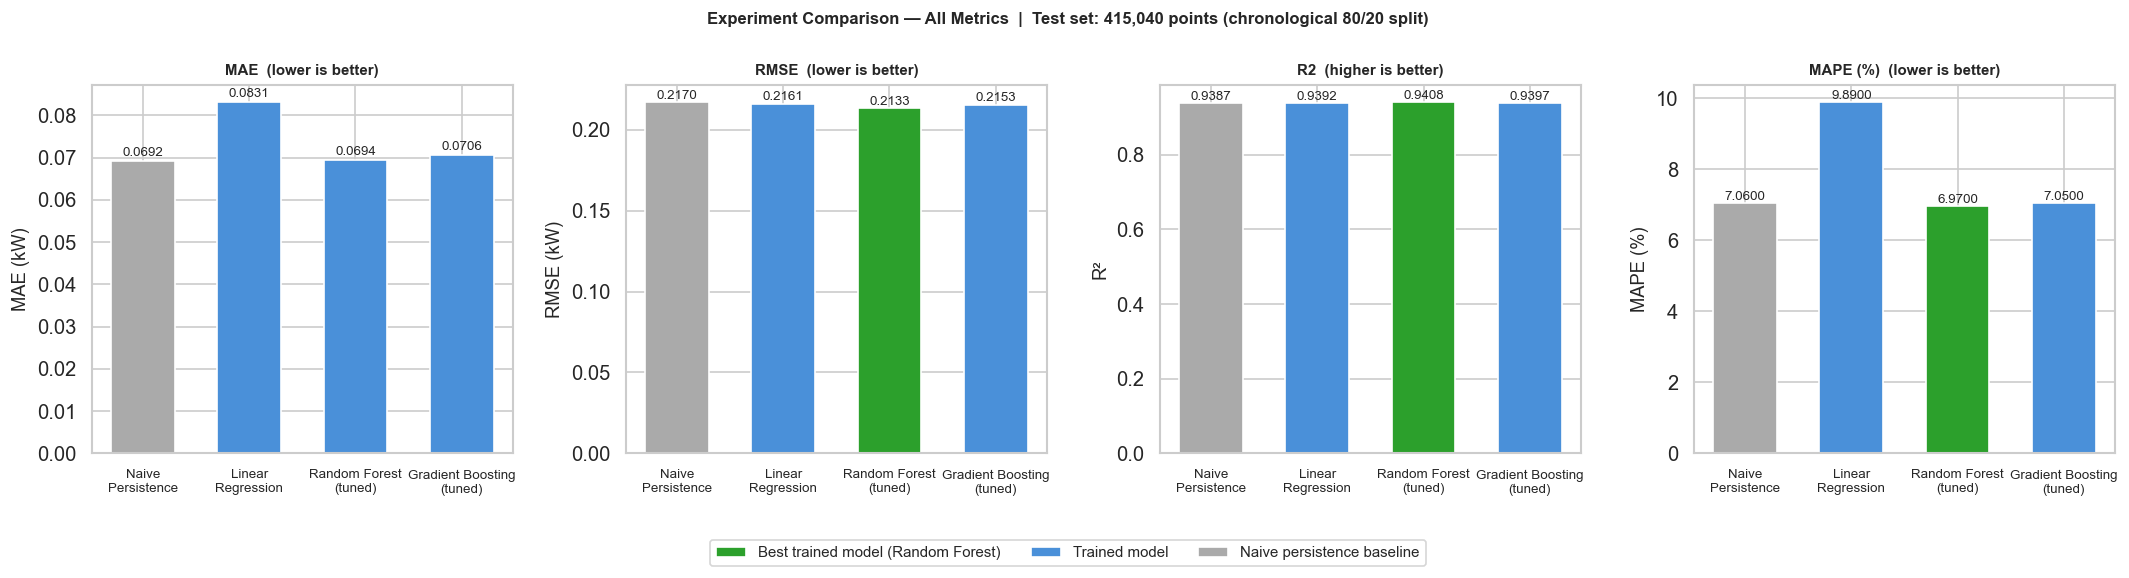

Saved: outputs/10_model_comparison_bar.png


In [227]:
results_df = pd.DataFrame(experiment_results)

naive_mae  = results_df.loc[results_df["Model"] == "Naive Persistence", "MAE"].values[0]
naive_rmse = results_df.loc[results_df["Model"] == "Naive Persistence", "RMSE"].values[0]

results_df["dMAE%"]  = ((naive_mae  - results_df["MAE"])  / naive_mae  * 100).round(2)
results_df["dRMSE%"] = ((naive_rmse - results_df["RMSE"]) / naive_rmse * 100).round(2)

trained   = results_df[results_df["Model"] != "Naive Persistence"].copy()
best_name = trained.loc[trained["RMSE"].idxmin(), "Model"]
best_row  = results_df[results_df["Model"] == best_name].iloc[0]

n_exps     = len(results_df) - 1
exp_labels = ["Baseline"] + [f"Exp {i}" for i in range(1, n_exps + 1)]
best_idx_in_df = results_df.index[results_df["Model"] == best_name][0]
exp_labels[best_idx_in_df] += " (Best)"

sep = "=" * 108
print(sep)
print("  EXPERIMENT RESULTS — Global Active Power Forecasting (1-min horizon)")
print(f"  Train: {len(X_train):,} pts  |  Test: {len(X_test):,} pts  |  Split: chronological 80/20")
print(f"  Full dataset: {len(df_model):,} rows (resampled to 1-min grid)")
print(sep)
print(f"{'Exp':<10} {'Model':<44} {'MAE':>7} {'RMSE':>7} {'R2':>7} {'MAPE%':>7} {'dMAE%':>8} {'dRMSE%':>8}")
print("-" * 108)
for lbl, (_, row) in zip(exp_labels, results_df.iterrows()):
    marker = " <-- best" if row["Model"] == best_name else ""
    print(f"{lbl:<10} {row['Model']:<44} {row['MAE']:>7.4f} {row['RMSE']:>7.4f} "
          f"{row['R2']:>7.4f} {row['MAPE (%)']:>7.2f} {row['dMAE%']:>+8.2f} {row['dRMSE%']:>+8.2f}{marker}")
print("-" * 108)
print("  dMAE% / dRMSE% = % change relative to Naive Persistence baseline  (+ve = improvement)")
print(sep)

print(f"\nRecommended model : {best_name}")
print(f"  RMSE = {best_row['RMSE']:.4f} kW  ({best_row['dRMSE%']:+.2f}% vs naive)")
print(f"  R2   = {best_row['R2']:.4f}")
print(f"  MAE  = {best_row['MAE']:.4f} kW")
print(f"  MAPE = {best_row['MAPE (%)']:.2f}%")

# Build params lookup defensively — avoids NameError if a cell was not run
_g = globals()
_params_map = {"Linear Regression": {"fit_intercept": True}}
if "rf_best_params" in _g:
    _params_map["Random Forest (tuned)"] = rf_best_params
if "gb_best_params" in _g:
    _params_map["Gradient Boosting (tuned, abs_error)"] = gb_best_params
best_hp = _params_map.get(best_name, {})
if best_hp:
    print(f"\nBest hyperparameters ({best_name}):")
    for k, v in best_hp.items():
        print(f"  {k:<22} = {v}")

_label_map = {
    "Naive Persistence":                    "Naive\nPersistence",
    "Linear Regression":                    "Linear\nRegression",
    "Random Forest (tuned)":                "Random Forest\n(tuned)",
    "Gradient Boosting (tuned, abs_error)": "Gradient Boosting\n(tuned)",
}
short_names  = [_label_map.get(m, m.split("(")[0].strip()) for m in results_df["Model"]]
metric_specs = [
    ("MAE",      "MAE (kW)",  False),
    ("RMSE",     "RMSE (kW)", False),
    ("R2",       "R²",        True),
    ("MAPE (%)", "MAPE (%)",  False),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (col, ylabel, higher_better) in zip(axes, metric_specs):
    best_val = results_df[col].max() if higher_better else results_df[col].min()
    clrs = []
    for m, v in zip(results_df["Model"], results_df[col]):
        if "Naive" in m:
            clrs.append("#aaaaaa")
        elif v == best_val:
            clrs.append("#2ca02c")
        else:
            clrs.append("#4a90d9")
    bars = ax.bar(range(len(results_df)), results_df[col], color=clrs, edgecolor="white", width=0.6)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(short_names, fontsize=8, ha="center")
    ax.set_ylabel(ylabel)
    direction = "lower is better" if not higher_better else "higher is better"
    ax.set_title(f"{col}  ({direction})", fontsize=9, fontweight="bold")
    for bar_patch, val in zip(bars, results_df[col]):
        ax.text(bar_patch.get_x() + bar_patch.get_width() / 2,
                bar_patch.get_height() + 0.0005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)

best_short = best_name.split("(")[0].strip()
legend_els = [
    mpatches.Patch(facecolor="#2ca02c", label=f"Best trained model ({best_short})"),
    mpatches.Patch(facecolor="#4a90d9", label="Trained model"),
    mpatches.Patch(facecolor="#aaaaaa", label="Naive persistence baseline"),
]
fig.legend(handles=legend_els, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.06), fontsize=9)
plt.suptitle(
    f"Experiment Comparison — All Metrics  |  Test set: {len(X_test):,} points (chronological 80/20 split)",
    fontsize=10, fontweight="bold"
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(OUTPUTS_DIR / "10_model_comparison_bar.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/10_model_comparison_bar.png")


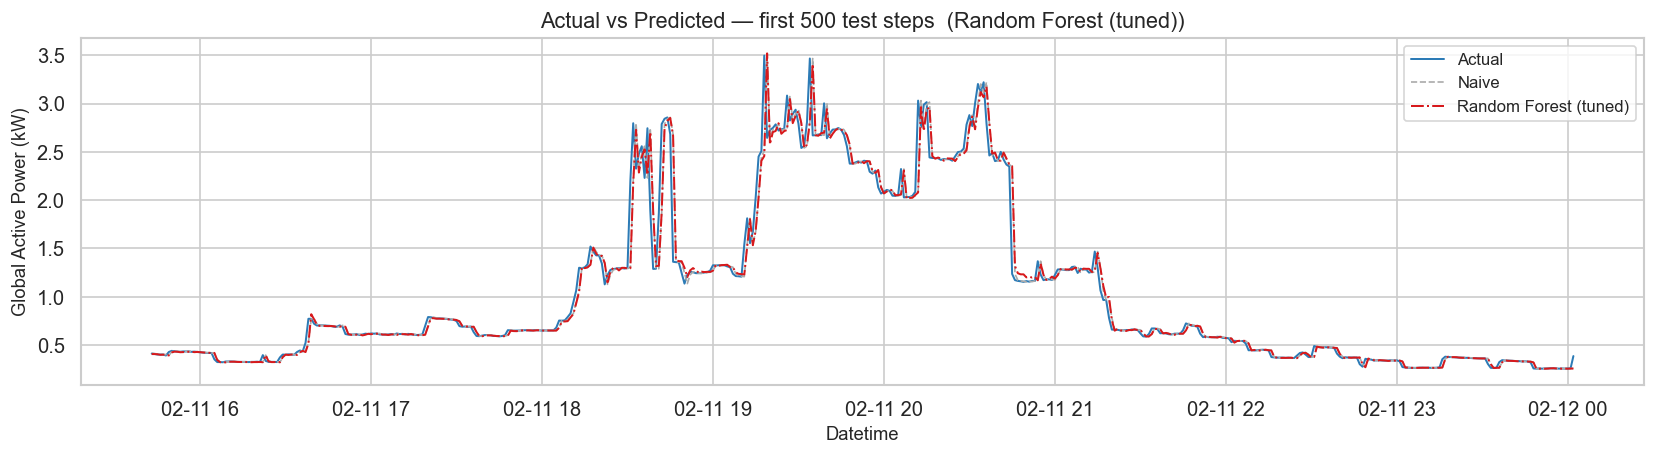

Saved: outputs/11_actual_vs_predicted.png


In [228]:
trained_models = {
    "Linear Regression":                    (y_pred_lr, scaler_lr),
    "Random Forest (tuned)":                (y_pred_rf, scaler_rf),
    "Gradient Boosting (tuned, abs_error)": (y_pred_gb, scaler_gb),
}
y_pred_best = trained_models[best_name][0]

n_plot = 500
t_plot = df_model["datetime"].iloc[-len(y_test):][:n_plot]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t_plot, y_test[:n_plot],      label="Actual",   lw=1.2, color="#2c7bb6")
ax.plot(t_plot, y_naive[:n_plot],     label="Naive",    lw=1,   ls="--", color="#aaaaaa")
ax.plot(t_plot, y_pred_best[:n_plot], label=best_name,  lw=1.2, ls="-.", color="#d7191c")
ax.set_title(f"Actual vs Predicted — first {n_plot} test steps  ({best_name})")
ax.set_xlabel("Datetime")
ax.set_ylabel("Global Active Power (kW)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "11_actual_vs_predicted.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/11_actual_vs_predicted.png")

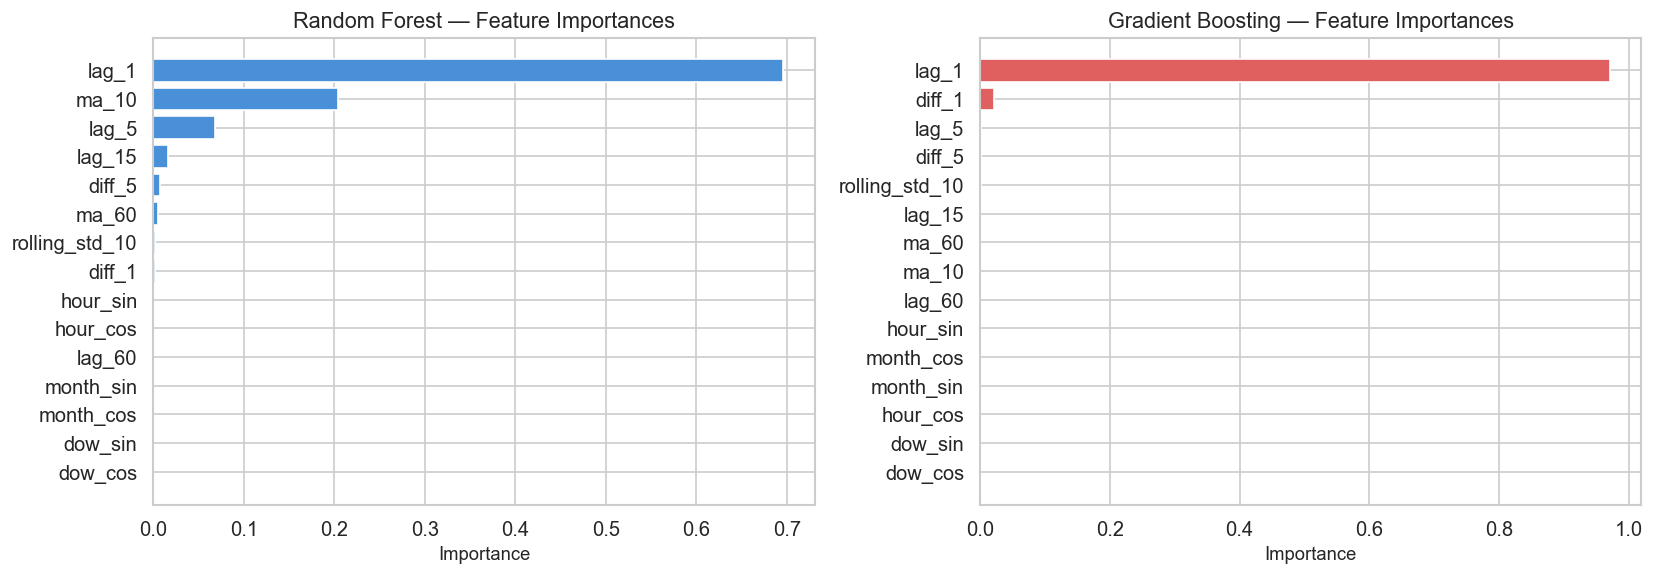

Saved: outputs/12_feature_importances.png

Top-3 RF : {'lag_1': 0.6959522447774723, 'ma_10': 0.20375208206366657, 'lag_5': 0.06806463117495933}
Top-3 GB : {'lag_1': 0.9703751131583871, 'diff_1': 0.02203946810437674, 'lag_5': 0.0018741554304449052}


In [229]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_imp = pd.Series(best_rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
axes[0].barh(rf_imp.index, rf_imp.values, color="#4a90d9")
axes[0].set_title("Random Forest — Feature Importances")
axes[0].set_xlabel("Importance")
axes[0].invert_yaxis()

gb_imp = pd.Series(best_gb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
axes[1].barh(gb_imp.index, gb_imp.values, color="#e06060")
axes[1].set_title("Gradient Boosting — Feature Importances")
axes[1].set_xlabel("Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "12_feature_importances.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/12_feature_importances.png")
print(f"\nTop-3 RF : {rf_imp.head(3).to_dict()}")
print(f"Top-3 GB : {gb_imp.head(3).to_dict()}")

In [230]:
DATA_DIR.mkdir(exist_ok=True)

# Save the best model — determined dynamically by lowest RMSE across all experiments
model_map = {
    "Linear Regression":                    (lr,      scaler_lr),
    "Random Forest (tuned)":                (best_rf, scaler_rf),
    "Gradient Boosting (tuned, abs_error)": (best_gb, scaler_gb),
}
model_to_save, scaler_to_save = model_map[best_name]

joblib.dump(model_to_save,  DATA_DIR / "best_model.joblib")
joblib.dump(scaler_to_save, DATA_DIR / "best_scaler.joblib")
with open(DATA_DIR / "feature_columns.json", "w") as f:
    json.dump(FEATURE_COLS, f)
with open(DATA_DIR / "experiment_results.json", "w") as f:
    json.dump(experiment_results, f, indent=2)

print(f"Saved: best_model.joblib   → {best_name}  ({type(model_to_save).__name__})")
print(f"Saved: best_scaler.joblib  → {type(scaler_to_save).__name__}")
print(f"Saved: feature_columns.json  ({len(FEATURE_COLS)} features)")
print(f"Saved: experiment_results.json  ({len(experiment_results)} entries)")
print(f"\nModel trained on : {len(X_train):,} rows  |  Tested on : {len(X_test):,} rows")
print(f"Best RMSE : {best_row['RMSE']:.4f} kW  |  R² : {best_row['R2']:.4f}")


Saved: best_model.joblib   → Random Forest (tuned)  (RandomForestRegressor)
Saved: best_scaler.joblib  → MinMaxScaler
Saved: feature_columns.json  (15 features)
Saved: experiment_results.json  (4 entries)

Model trained on : 1,660,159 rows  |  Tested on : 415,040 rows
Best RMSE : 0.2133 kW  |  R² : 0.9408


---
## Summary — Task 1: EDA and Forecasting Pipeline

### Dataset

The UCI Individual Household Electric Power Consumption dataset covers 16 December 2006 to 26 November 2010 at one-minute granularity. After resampling to a complete one-minute grid and linearly interpolating the 1.252% of missing rows, the processed dataset contains 2,075,259 rows. The target variable is `global_active_power` (kW).

### Feature Engineering

Fifteen leakage-free features are constructed entirely from past observations. Six cyclic temporal features (`hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos`) encode time-of-day, day-of-week, and month-of-year as sine/cosine pairs to preserve circular distance without ordinal discontinuities. Four lag features (`lag_1`, `lag_5`, `lag_15`, `lag_60`) exploit the strong autocorrelation confirmed in Q3. Two momentum features (`diff_1`, `diff_5`) encode the rate and direction of recent change. Two smoothed trend features (`ma_10`, `ma_60`) provide a local consumption baseline via past-window rolling means. The `rolling_std_10` feature captures local predictability. All rolling and lag operations use `.shift(1)` so no value at time $t$ is used as input. Contemporaneous variables (`global_intensity`, `voltage`, `global_reactive_power`) are excluded to prevent data leakage.

### Model Training

Three experiments were conducted under a strict chronological 80/20 split with no shuffling. Experiment 1 is Linear Regression (OLS baseline). Experiment 2 is Random Forest with hyperparameters selected via `RandomizedSearchCV` and `TimeSeriesSplit(n_splits=3)`. Experiment 3 is Gradient Boosting with the same search strategy. Both tree models are tuned on the most recent 100,000 training rows (chronological tail) to preserve temporal structure, then retrained on the full training set. The recommended model is the one achieving the lowest RMSE and highest R² on the held-out test set, as reported in the experiment comparison table above.
